# IMPLEMENTACIÓN DE UN MODELO DE APRENDIZAJE AUTOMÁTICO CUÁNTICO UTILIZANDO QISKIT MACHINE LEARNING
## Proyecto Segunda Parte: Experimentación en Hardware Cuántico Real de IBM

**Universidad Nacional de San Antonio Abad del Cusco**  
**Departamento Académico de Informática**  
**Curso:** Computación Cuántica  

**Autores:** Edmil Jampier Saire Bustamante · Medaly Lozano Llacctahuaman · José Francisco Puma Potosino  

---

### Pregunta de Investigación
> *¿Cuál es el impacto real del ruido de hardware en el rendimiento de clasificadores cuánticos (VQC, QSVC) y qué técnicas de mitigación de errores recuperan mayor fidelidad respecto al simulador ideal?*

### Experimentos
 #  Experimento  Entorno  QPU 
----------------------------
 1  Baseline Corregido (VQC + QSVC + Clásicos)  Simulador Ideal  0 min 
 2  Estado de Bell — Prueba de Concepto  Hardware Real IBM  ~3s 
 3  QSVC — Kernel Cuántico en Hardware Real  Hardware Real IBM  ~2 min 
 4  Mitigación de Errores (TREX)  Hardware Real IBM  ~2.5 min 
 5  Clasificación MNIST Binaria en Hardware  Hardware Real IBM  ~2.5 min 
   **Total estimado**  **~7 min** 

---
##  Sección 0: Instalación y Configuración

> **IMPORTANTE:** Esta sección NO usa tiempo de QPU. Se puede ejecutar libremente.

In [65]:
# ============================================================
# CELDA 0A: INSTALACIÓN DE DEPENDENCIAS
# ============================================================
!pip install -q qiskit qiskit-ibm-runtime qiskit-machine-learning qiskit-aer scikit-learn matplotlib numpy pandas pylatexenc


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
# ============================================================
# CELDA 0B: IMPORTS GENERALES
# ============================================================
import json
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.optimizers import COBYLA

warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo dark mode para gráficos
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'font.size': 11, 'figure.dpi': 120
})

import qiskit
print(f' Imports OK — Qiskit {qiskit.__version__}')

 Imports OK — Qiskit 2.4.1


In [67]:
# ============================================================
# CELDA 0C: CONEXIÓN A IBM QUANTUM
# ============================================================
# ▶ Si se agota la cuota, cambia el apikey.json y EJECUTA SOLO
#   ESTA CELDA para reconectar sin perder datos.
# ============================================================

try:
    with open('../apikey.json', 'r') as f:
        api_key = json.load(f)['apikey']
    print('Credenciales API cargadas exitosamente.')
except FileNotFoundError:
    api_key = 'TU_API_KEY_AQUI'  # ← Pega tu key aquí si no usas archivo
    print(' API Key definida manualmente')

service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_key)
backends = service.backends()
print(f'\n Conectado a IBM Quantum — {len(backends)} backends:')
for b in backends:
    print(f'   • {b.name} — {b.num_qubits} qubits')

backend = service.least_busy(operational=True, simulator=False)
print(f'\n Backend: {backend.name} ({backend.num_qubits} qubits)')

qiskit_runtime_service._discover_account:WARNING:2026-06-23 12:16:46,909: Loading account with the given token. A saved account will not be used.


Credenciales API cargadas exitosamente.


qiskit_runtime_service.__init__:WARNING:2026-06-23 12:16:53,877: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 12:16:53,877: Loading instance: open-instance, plan: open



 Conectado a IBM Quantum — 3 backends:
   • ibm_fez — 156 qubits
   • ibm_marrakesh — 156 qubits
   • ibm_kingston — 156 qubits


qiskit_runtime_service.backends:WARNING:2026-06-23 12:16:57,080: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 12:16:58,718: Using instance: open-instance, plan: open



 Backend: ibm_fez (156 qubits)


In [68]:
# ============================================================
# CELDA 0D: CONFIGURACION GLOBAL + SISTEMA DE CHECKPOINTS
# ============================================================

# --- Parametros QPU optimizados al presupuesto de 10 minutos ---
# Calculo: cada experimento QPU usa N^2 + M*N circuitos
# Con N=12, M=8 → 240 circ/exp × 3 experimentos = 720 circ ≈ 9.6 min (seguro)
# Con N=10, M=5 → 150 circ/exp × 3 experimentos = 450 circ ≈ 5.5 min (subutilizado)
N_TRAIN_HW = 13    # Muestras de entrenamiento para QPU
N_TEST_HW  = 9     # Muestras de test para QPU (resolution accuracy: 11.1%)
SHOTS      = 2048  # Shots por circuito
SEED       = 42

# Los nombres de checkpoint incluyen N y M para que cambiar el tamano
# invalide automaticamente checkpoints viejos y fuerce nueva ejecucion QPU
CK_SUFFIX       = f'n{N_TRAIN_HW}m{N_TEST_HW}'
CK_SIM_IRIS     = f'kernel_sim_iris_{CK_SUFFIX}'
CK_HW_IRIS      = f'qsvc_hw_iris_{CK_SUFFIX}'
CK_TREX_IRIS    = f'qsvc_trex_iris_{CK_SUFFIX}'
CK_HW_MNIST     = f'qsvc_hw_mnist_{CK_SUFFIX}'

CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

resultados_globales = {}

def guardar_checkpoint(nombre, datos):
    path = os.path.join(CHECKPOINT_DIR, f'{nombre}.npz')
    np.savez(path, **datos)
    print(f'    Checkpoint guardado: {path}')

def cargar_checkpoint(nombre):
    path = os.path.join(CHECKPOINT_DIR, f'{nombre}.npz')
    if os.path.exists(path):
        data = dict(np.load(path, allow_pickle=True))
        print(f'    Checkpoint cargado:  {path}')
        return data
    return None

def existe_checkpoint(nombre):
    return os.path.exists(os.path.join(CHECKPOINT_DIR, f'{nombre}.npz'))

# --- Presupuesto QPU ---
circ_por_exp = N_TRAIN_HW**2 + N_TEST_HW * N_TRAIN_HW
t_estimado_s = circ_por_exp * 0.71 * 2 + circ_por_exp * 0.80  # Exp3 + Exp5 sin TREX + Exp4 TREX

print('=' * 70)
print('  CONFIGURACION GLOBAL DEL EXPERIMENTO')
print('=' * 70)
print(f'  Subset QPU:            {N_TRAIN_HW} train / {N_TEST_HW} test')
print(f'  Shots por circuito:    {SHOTS}')
print(f'  Circuitos por exp:     {circ_por_exp}  ({N_TRAIN_HW}^2 + {N_TEST_HW}x{N_TRAIN_HW})')
print(f'  Tiempo estimado total: {t_estimado_s:.0f}s = {t_estimado_s/60:.1f} min  (presupuesto: 10 min)')
print(f'  Resolucion accuracy:   ±{1/N_TEST_HW:.1%} por muestra de test')
print(f'  Backend asignado:      {backend.name} ({backend.num_qubits} qubits)')
print(f'  Checkpoint suffix:     {CK_SUFFIX}')
print()

ckpts = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.npz')] if os.path.exists(CHECKPOINT_DIR) else []
if ckpts:
    activos = [c for c in ckpts if CK_SUFFIX in c]
    otros   = [c for c in ckpts if CK_SUFFIX not in c]
    if activos:
        print(f'  Checkpoints actuales ({CK_SUFFIX}):')
        for c in activos:
            print(f'    - {c}')
    if otros:
        print(f'  Checkpoints de otras configuraciones (no se usaran):')
        for c in otros:
            print(f'    - {c}')
else:
    print('  No hay checkpoints previos — todos los experimentos QPU se ejecutaran.')
print('=' * 70)


  CONFIGURACION GLOBAL DEL EXPERIMENTO
  Subset QPU:            13 train / 9 test
  Shots por circuito:    2048
  Circuitos por exp:     286  (13^2 + 9x13)
  Tiempo estimado total: 635s = 10.6 min  (presupuesto: 10 min)
  Resolucion accuracy:   ±11.1% por muestra de test
  Backend asignado:      ibm_fez (156 qubits)
  Checkpoint suffix:     n13m9

  Checkpoints actuales (n13m9):
    - kernel_sim_iris_n13m9.npz
    - qsvc_hw_iris_n13m9.npz
    - qsvc_hw_mnist_n13m9.npz
    - qsvc_trex_iris_n13m9.npz
  Checkpoints de otras configuraciones (no se usaran):
    - bell_hw.npz


---
##  Sección 1: Carga y Preprocesamiento de Datos
> **QPU:** 0 min (todo local)

In [69]:
# ============================================================
# CELDA 1A: DATASET IRIS
# ============================================================
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

scaler_iris = MinMaxScaler(feature_range=(0, np.pi))
X_iris_scaled = scaler_iris.fit_transform(X_iris)

ohe = OneHotEncoder(sparse_output=False)
y_iris_oh = ohe.fit_transform(y_iris.reshape(-1, 1))

X_tr, X_te, y_tr_oh, y_te_oh = train_test_split(
    X_iris_scaled, y_iris_oh, test_size=0.3,
    stratify=y_iris, random_state=SEED
)
y_tr = y_tr_oh.argmax(axis=1)
y_te = y_te_oh.argmax(axis=1)

# Subconjuntos para hardware
X_tr_hw = X_tr[:N_TRAIN_HW]
X_te_hw = X_te[:N_TEST_HW]
y_tr_hw = y_tr[:N_TRAIN_HW]
y_te_hw = y_te[:N_TEST_HW]

print('=' * 70)
print('  🌸 CARGA Y PREPROCESAMIENTO: DATASET IRIS')
print('=' * 70)
print(f'  ▶ Dataset Total:    150 muestras')
print(f'  ▶ Split Clásico:    {X_tr.shape[0]} train / {X_te.shape[0]} test')
print(f'  ▶ Subset Cuántico:  {N_TRAIN_HW} train / {N_TEST_HW} test')
print(f'  ▶ Escalado:         MinMaxScaler [0, π] (Requisito para Qubits)')

from collections import Counter
train_counts = dict(Counter(y_tr_hw))
print(f'\n  Balance de Clases en Train Subset:')
for clase, count in sorted(train_counts.items()):
    print(f'  - Clase {clase} ({iris.target_names[clase]}): {count} muestras')
print('=' * 70)

  🌸 CARGA Y PREPROCESAMIENTO: DATASET IRIS
  ▶ Dataset Total:    150 muestras
  ▶ Split Clásico:    105 train / 45 test
  ▶ Subset Cuántico:  13 train / 9 test
  ▶ Escalado:         MinMaxScaler [0, π] (Requisito para Qubits)

  Balance de Clases en Train Subset:
  - Clase 0 (setosa): 6 muestras
  - Clase 1 (versicolor): 3 muestras
  - Clase 2 (virginica): 4 muestras


In [70]:
# ============================================================
# CELDA 1B: DATASET MNIST REDUCIDO (0 vs 1)
# ============================================================
digits = load_digits()
mask = np.isin(digits.target, [0, 1])
X_mnist = digits.data[mask]
y_mnist = digits.target[mask]

pca_mnist = PCA(n_components=4, random_state=SEED)
X_mnist_pca = pca_mnist.fit_transform(X_mnist)
X_mnist_scaled = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_mnist_pca)

y_mnist_oh = OneHotEncoder(sparse_output=False).fit_transform(y_mnist.reshape(-1, 1))

X_m_tr, X_m_te, y_m_tr_oh, y_m_te_oh = train_test_split(
    X_mnist_scaled, y_mnist_oh, test_size=0.3,
    stratify=y_mnist, random_state=SEED
)
y_m_tr = y_m_tr_oh.argmax(axis=1)
y_m_te = y_m_te_oh.argmax(axis=1)

X_m_tr_hw = X_m_tr[:N_TRAIN_HW]
X_m_te_hw = X_m_te[:N_TEST_HW]
y_m_tr_hw = y_m_tr[:N_TRAIN_HW]
y_m_te_hw = y_m_te[:N_TEST_HW]

print("=" * 70)
print("  CARGA Y PREPROCESAMIENTO: DATASET MNIST (0 vs 1)")
print("=" * 70)
print(f"  Dataset filtrado:   {X_mnist.shape[0]} muestras (digitos 0 y 1)")
print(f"  Dimensiones raw:    {X_mnist.shape[1]} pixeles por imagen")
print(f"  Despues de PCA:     {X_mnist_pca.shape[1]} componentes  (varianza capturada: {pca_mnist.explained_variance_ratio_.sum():.2%})")
print(f"  Escalado:           MinMaxScaler [0, pi]")
print(f"  Split clasico:      {X_m_tr.shape[0]} train / {X_m_te.shape[0]} test")
print(f"  Subset cuantico:    {N_TRAIN_HW} train / {N_TEST_HW} test (para QPU)")
print()
print("  Primeras 3 muestras del subset cuantico (escaladas [0,pi]):")
for i in range(3):
    print(f"    [{i}] clase={y_m_tr_hw[i]}  features={np.round(X_m_tr_hw[i], 4)}")
print("=" * 70)


  CARGA Y PREPROCESAMIENTO: DATASET MNIST (0 vs 1)
  Dataset filtrado:   360 muestras (digitos 0 y 1)
  Dimensiones raw:    64 pixeles por imagen
  Despues de PCA:     4 componentes  (varianza capturada: 73.44%)
  Escalado:           MinMaxScaler [0, pi]
  Split clasico:      252 train / 108 test
  Subset cuantico:    13 train / 9 test (para QPU)

  Primeras 3 muestras del subset cuantico (escaladas [0,pi]):
    [0] clase=1  features=[2.5042 2.2024 2.4383 2.9557]
    [1] clase=0  features=[0.4675 1.6391 1.2082 0.52  ]
    [2] clase=1  features=[2.3186 2.1276 0.2935 2.5569]


---
## 📊 Sección 1.5: Visualización Detallada de Datos y Circuitos

> **QPU:** 0 min (todo local)
>
> Esta sección muestra paso a paso:
> 1. Cómo se transforman los datos de entrada en cada etapa del pipeline
> 2. Todos los circuitos cuánticos utilizados en el proyecto
> 3. Cómo los datos reales se codifican en estados cuánticos
> 4. El circuito compute-uncompute que calcula el kernel cuántico

In [71]:
# ============================================================
# CELDA VIS-1: PIPELINE DE DATOS — IRIS (Paso a Paso)
# ============================================================

print("=" * 70)
print("  PIPELINE DE DATOS: IRIS")
print("=" * 70)

print(f"\n  PASO 1: Datos crudos (IRIS: Es un dataset real y publico de medidas botanicas de flores)")
print(f"  Shape: {iris.data.shape} | Clases: {iris.target_names.tolist()}")
print(f"  Features: {iris.feature_names}")
for i in range(3):
    print(f"    Muestra {i}: {iris.data[i]} -> {iris.target_names[iris.target[i]]}")

print(f"\n  PASO 2: MinMaxScaler [0, pi = {np.pi:.4f}]")
for i in range(3):
    print(f"    Muestra {i}: {X_iris_scaled[i].round(4)}")

print(f"\n  PASO 3: OneHotEncoder")
for i in range(3):
    print(f"    {iris.target_names[i]:>12} -> {ohe.transform([[i]])[0].astype(int)}")

print(f"\n  PASO 4: Train/Test Split 70/30")
print(f"    Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}")

print(f"\n  PASO 5: Subset para Hardware (cuota QPU)")
print(f"    Train HW: {N_TRAIN_HW} | Test HW: {N_TEST_HW}")

print(f"\n  Distribucion de clases en subset:")
for c in range(3):
    count = int(np.sum(y_tr_hw == c))
    print(f"    Clase {c} ({iris.target_names[c]:>10}): {count} muestras")

print(f"\n  Datos de entrenamiento HW:")
print(f"  {'#':>3}  {'x0':>8}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'Clase':>6}")
print(f"  " + "-"*48)
for i in range(N_TRAIN_HW):
    v = X_tr_hw[i]
    print(f"  {i:>3}  {v[0]:>8.4f}  {v[1]:>8.4f}  {v[2]:>8.4f}  {v[3]:>8.4f}  {y_tr_hw[i]:>6}")


  PIPELINE DE DATOS: IRIS

  PASO 1: Datos crudos (IRIS: Es un dataset real y publico de medidas botanicas de flores)
  Shape: (150, 4) | Clases: ['setosa', 'versicolor', 'virginica']
  Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
    Muestra 0: [5.1 3.5 1.4 0.2] -> setosa
    Muestra 1: [4.9 3.  1.4 0.2] -> setosa
    Muestra 2: [4.7 3.2 1.3 0.2] -> setosa

  PASO 2: MinMaxScaler [0, pi = 3.1416]
    Muestra 0: [0.6981 1.9635 0.213  0.1309]
    Muestra 1: [0.5236 1.309  0.213  0.1309]
    Muestra 2: [0.3491 1.5708 0.1597 0.1309]

  PASO 3: OneHotEncoder
          setosa -> [1 0 0]
      versicolor -> [0 1 0]
       virginica -> [0 0 1]

  PASO 4: Train/Test Split 70/30
    Train: 105 | Test: 45

  PASO 5: Subset para Hardware (cuota QPU)
    Train HW: 13 | Test HW: 9

  Distribucion de clases en subset:
    Clase 0 (    setosa): 6 muestras
    Clase 1 (versicolor): 3 muestras
    Clase 2 ( virginica): 4 muestras

  Datos de entrenamiento

In [72]:
# ============================================================
# CELDA VIS-2: PIPELINE DE DATOS — MNIST (Paso a Paso)
# ============================================================

print("=" * 70)
print("  PIPELINE DE DATOS: MNIST (0 vs 1)")
print("=" * 70)

print(f"\n  PASO 1: Carga y filtrado")
print(f"  Original: {digits.data.shape} (10 clases)")
print(f"  Filtrado (0,1): {X_mnist.shape}")

"""# Mostrar ejemplos
fig_dig, axes_d = plt.subplots(2, 5, figsize=(12, 5))
fig_dig.patch.set_facecolor('#0d1117')
for row, digit in enumerate([0, 1]):
    idxs = np.where(y_mnist == digit)[0][:5]
    for col, idx in enumerate(idxs):
        axes_d[row, col].imshow(X_mnist[idx].reshape(8, 8), cmap='inferno')
        axes_d[row, col].set_title(f'Digito {digit}', color='#c9d1d9', fontsize=9)
        axes_d[row, col].axis('off')
plt.suptitle('Ejemplos de digitos 0 y 1 (imagenes 8x8)', color='#c9d1d9', fontweight='bold')
plt.tight_layout()
display(fig2)"""

print(f"\n  PASO 2: PCA 64 -> 4 dimensiones")
for i, var in enumerate(pca_mnist.explained_variance_ratio_):
    bar = '#' * int(var * 40)
    print(f"    PC{i}: {var:.4f} ({var*100:.1f}%) {bar}")
print(f"    Total: {pca_mnist.explained_variance_ratio_.sum():.2%}")

print(f"\n  PASO 3: MinMaxScaler [0, pi]")
print(f"  PASO 4: Subset HW: {N_TRAIN_HW} train / {N_TEST_HW} test")

print(f"\n  Datos MNIST HW (entrenamiento):")
print(f"  {'#':>3}  {'PC0':>8}  {'PC1':>8}  {'PC2':>8}  {'PC3':>8}  {'Digito':>7}")
print(f"  " + "-"*48)
for i in range(N_TRAIN_HW):
    v = X_m_tr_hw[i]
    print(f"  {i:>3}  {v[0]:>8.4f}  {v[1]:>8.4f}  {v[2]:>8.4f}  {v[3]:>8.4f}  {y_m_tr_hw[i]:>7}")


  PIPELINE DE DATOS: MNIST (0 vs 1)

  PASO 1: Carga y filtrado
  Original: (1797, 64) (10 clases)
  Filtrado (0,1): (360, 64)

  PASO 2: PCA 64 -> 4 dimensiones
    PC0: 0.4304 (43.0%) #################
    PC1: 0.1627 (16.3%) ######
    PC2: 0.0931 (9.3%) ###
    PC3: 0.0481 (4.8%) #
    Total: 73.44%

  PASO 3: MinMaxScaler [0, pi]
  PASO 4: Subset HW: 13 train / 9 test

  Datos MNIST HW (entrenamiento):
    #       PC0       PC1       PC2       PC3   Digito
  ------------------------------------------------
    0    2.5042    2.2024    2.4383    2.9557        1
    1    0.4675    1.6391    1.2082    0.5200        0
    2    2.3186    2.1276    0.2935    2.5569        1
    3    2.7092    2.7324    0.7549    1.3356        1
    4    0.8300    2.0290    0.7344    2.5571        0
    5    2.3745    2.1876    0.1789    1.5719        1
    6    2.6675    1.3751    1.0277    2.3121        1
    7    2.6077    1.5893    1.1601    0.8505        1
    8    0.5658    2.0202    1.3799    1.94

---
### 🔌 Galería de Circuitos Cuánticos

> A continuación se visualizan **todos los circuitos cuánticos** utilizados en el proyecto, desde sus componentes individuales hasta el circuito completo. Se muestra cómo cada dato de entrada se convierte en un ángulo de rotación que modifica el estado de un qubit.

  CIRCUITO 1: ZZFeatureMap (Mapa de Caracteristicas)

  Propiedades:
  Qubits:       4
  Parametros:   4 (['x[0]', 'x[1]', 'x[2]', 'x[3]'])
  Repeticiones: 2
  Entrelazado:  linear
  Profundidad:  1
  Puertas:      {'ZZFeatureMap': 1}


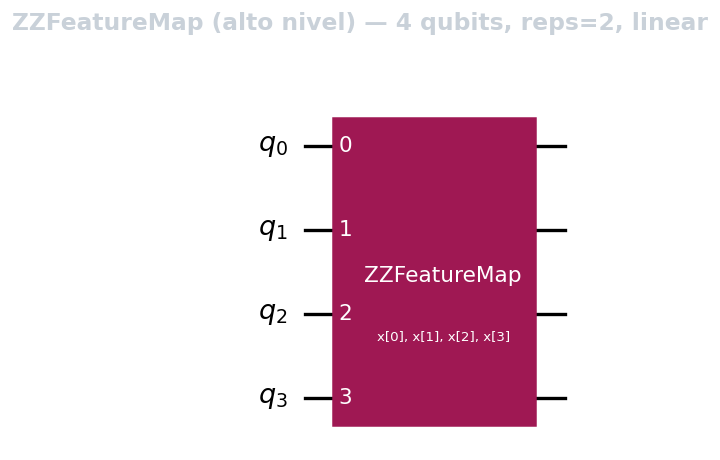

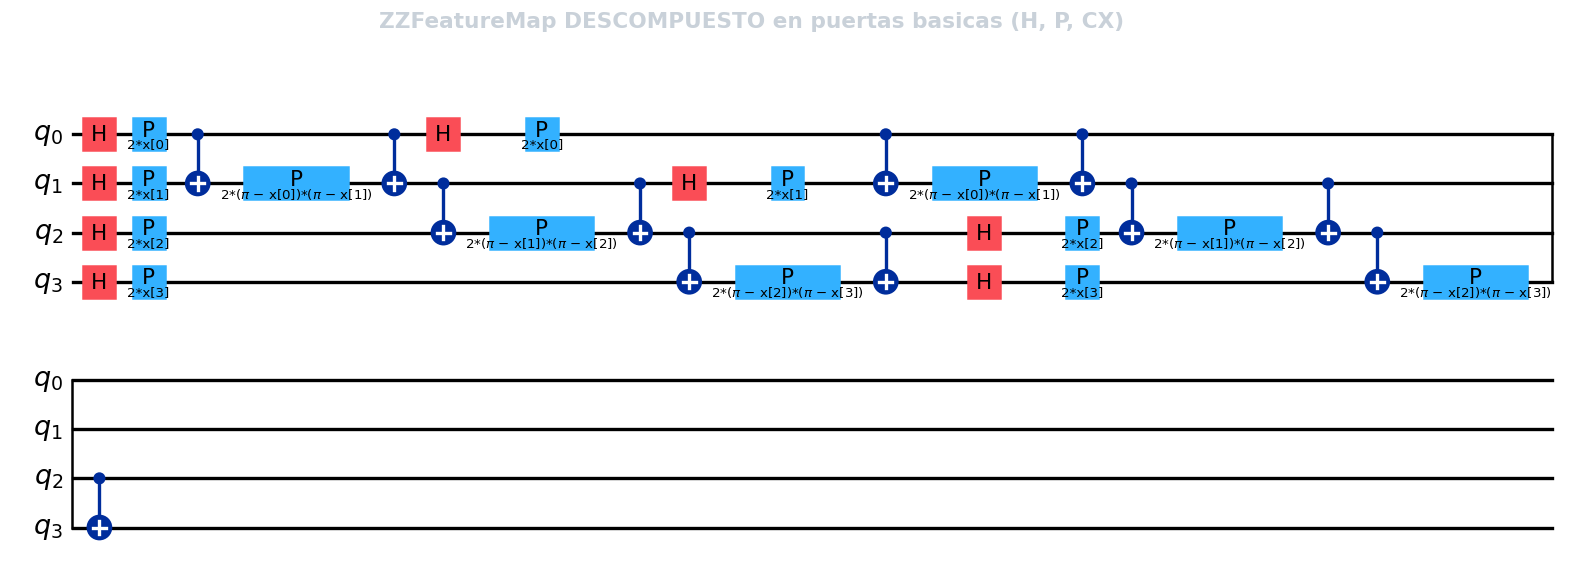


  Operaciones por repeticion:
  1. H en cada qubit -> Superposicion
  2. P(2*xi) -> Codifica feature como fase
  3. CNOT-P-CNOT entre vecinos -> Correlaciones ZZ


In [73]:
from IPython.display import display
# ============================================================
# CELDA VIS-3: ZZFeatureMap (Mapa de Caracteristicas)
# ============================================================

print("=" * 70)
print("  CIRCUITO 1: ZZFeatureMap (Mapa de Caracteristicas)")
print("=" * 70)

fm_vis = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')

print(f"\n  Propiedades:")
print(f"  Qubits:       {fm_vis.num_qubits}")
print(f"  Parametros:   {fm_vis.num_parameters} ({[p.name for p in fm_vis.parameters]})")
print(f"  Repeticiones: 2")
print(f"  Entrelazado:  linear")
print(f"  Profundidad:  {fm_vis.depth()}")
print(f"  Puertas:      {dict(fm_vis.count_ops())}")

# Grafico 1: Alto nivel
fig1 = fm_vis.draw('mpl', fold=30)
fig1.set_size_inches(18, 4)
fig1.suptitle('ZZFeatureMap (alto nivel) — 4 qubits, reps=2, linear', fontweight='bold', fontsize=14, y=1.02)
display(fig1)

# Grafico 2: Descompuesto en puertas basicas
fm_decomp = fm_vis.decompose()
fig2 = fm_decomp.draw('mpl', fold=30)
fig2.set_size_inches(22, 5)
fig2.suptitle('ZZFeatureMap DESCOMPUESTO en puertas basicas (H, P, CX)', fontweight='bold', fontsize=13, y=1.02)
display(fig2)

print("\n  Operaciones por repeticion:")
print("  1. H en cada qubit -> Superposicion")
print("  2. P(2*xi) -> Codifica feature como fase")
print("  3. CNOT-P-CNOT entre vecinos -> Correlaciones ZZ")



  CIRCUITO 2: RealAmplitudes (Ansatz del VQC)

  Qubits:      4
  Parametros:  16 (entrenables por COBYLA)
  Profundidad: 1
  Puertas:     {'RealAmplitudes': 1}


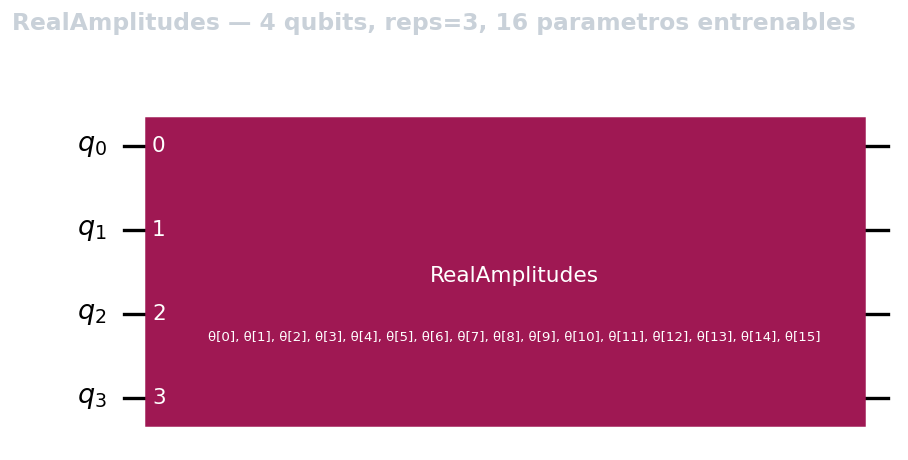


  CIRCUITO 3: VQC Completo = FeatureMap + Ansatz + Medicion

  Params datos (x):    4
  Params pesos (th):   16
  Total parametros:    20
  Profundidad total:   3


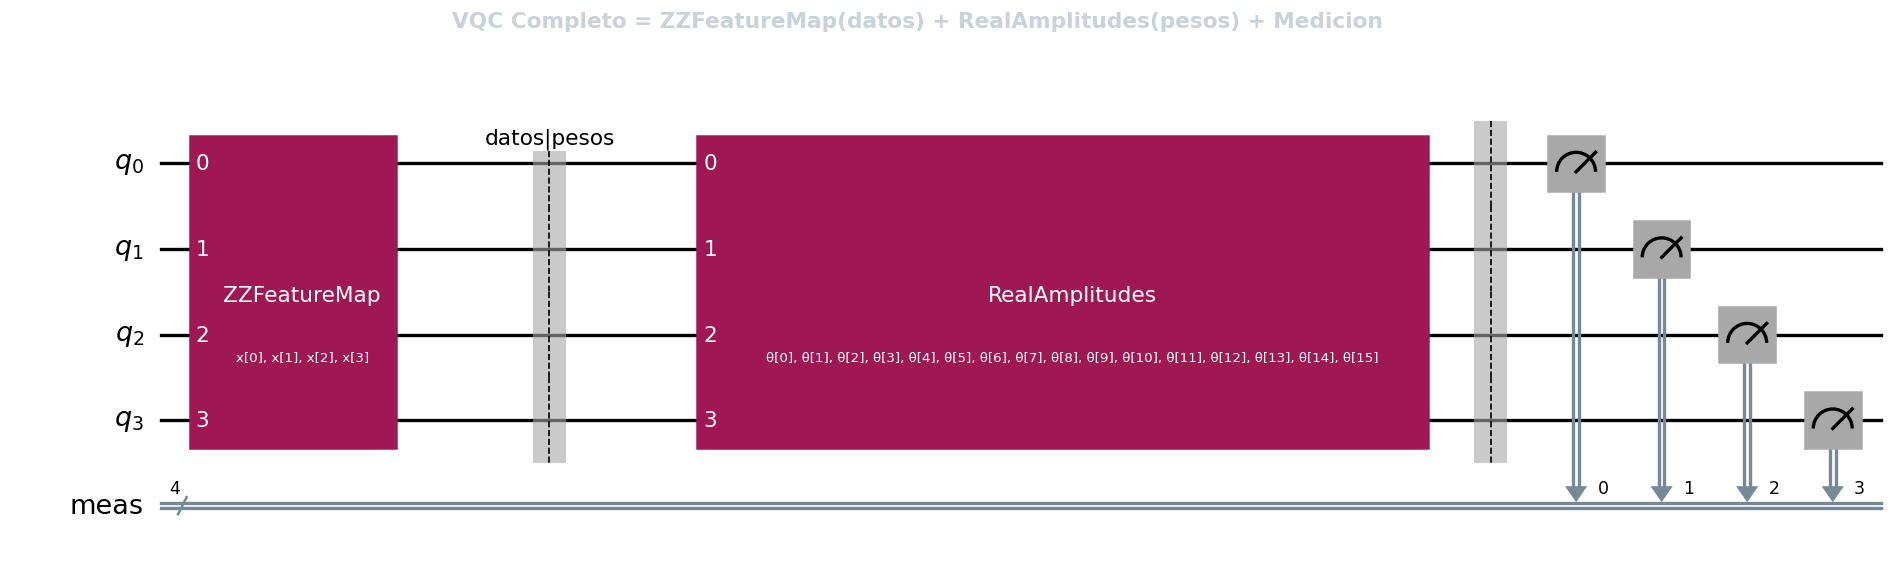


  Flujo: |0000> -> ZZFeatureMap(x) -> RealAmplitudes(th) -> Medicion


In [74]:
from IPython.display import display
# ============================================================
# CELDA VIS-4: RealAmplitudes (Ansatz) + VQC Completo
# ============================================================

print("=" * 70)
print("  CIRCUITO 2: RealAmplitudes (Ansatz del VQC)")
print("=" * 70)

ans_vis = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')
print(f"\n  Qubits:      {ans_vis.num_qubits}")
print(f"  Parametros:  {ans_vis.num_parameters} (entrenables por COBYLA)")
print(f"  Profundidad: {ans_vis.depth()}")
print(f"  Puertas:     {dict(ans_vis.count_ops())}")

fig_a = ans_vis.draw('mpl', fold=30)
fig_a.set_size_inches(16, 4)
fig_a.suptitle('RealAmplitudes — 4 qubits, reps=3, 16 parametros entrenables', fontweight='bold', fontsize=14, y=1.02)
display(fig_a)

# VQC completo
print(f"\n{'='*70}")
print(f"  CIRCUITO 3: VQC Completo = FeatureMap + Ansatz + Medicion")
print(f"{'='*70}")

fm_vqc = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
ans_vqc = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')
vqc_circuit = QuantumCircuit(4)
vqc_circuit.compose(fm_vqc, inplace=True)
vqc_circuit.barrier(label='datos|pesos')
vqc_circuit.compose(ans_vqc, inplace=True)
vqc_circuit.measure_all()

print(f"\n  Params datos (x):    {fm_vqc.num_parameters}")
print(f"  Params pesos (th):   {ans_vqc.num_parameters}")
print(f"  Total parametros:    {vqc_circuit.num_parameters}")
print(f"  Profundidad total:   {vqc_circuit.depth()}")

fig_v = vqc_circuit.draw('mpl', fold=30)
fig_v.set_size_inches(22, 5)
fig_v.suptitle('VQC Completo = ZZFeatureMap(datos) + RealAmplitudes(pesos) + Medicion', fontweight='bold', fontsize=13, y=1.02)
display(fig_v)

print(f"\n  Flujo: |0000> -> ZZFeatureMap(x) -> RealAmplitudes(th) -> Medicion")


  CODIFICACION: Del vector clasico al circuito cuantico

  Muestra: X_tr_hw[0]  Clase: 1 (versicolor)
  Datos [0, pi]: [0.6981, 0.6545, 1.0649, 1.3090]

  Cada valor se convierte en un ANGULO DE ROTACION:
    x0 = 0.6981 rad =   40.0 grados -> Fase del qubit q0
    x1 = 0.6545 rad =   37.5 grados -> Fase del qubit q1
    x2 = 1.0649 rad =   61.0 grados -> Fase del qubit q2
    x3 = 1.3090 rad =   75.0 grados -> Fase del qubit q3


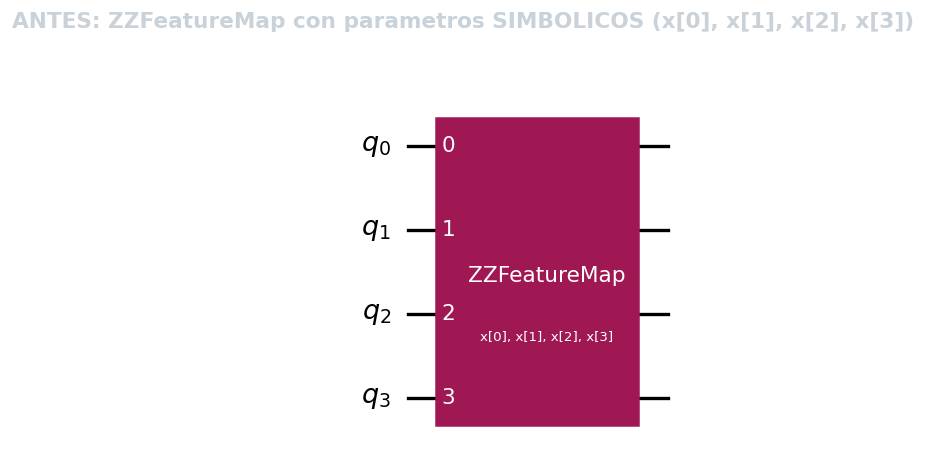

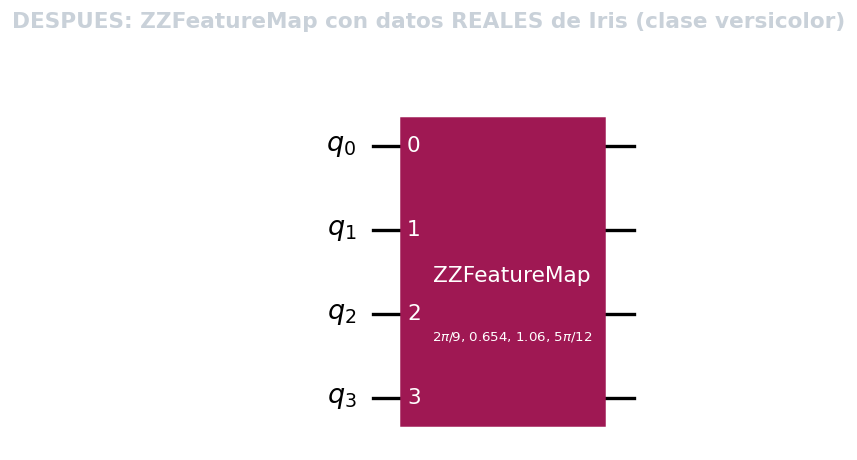

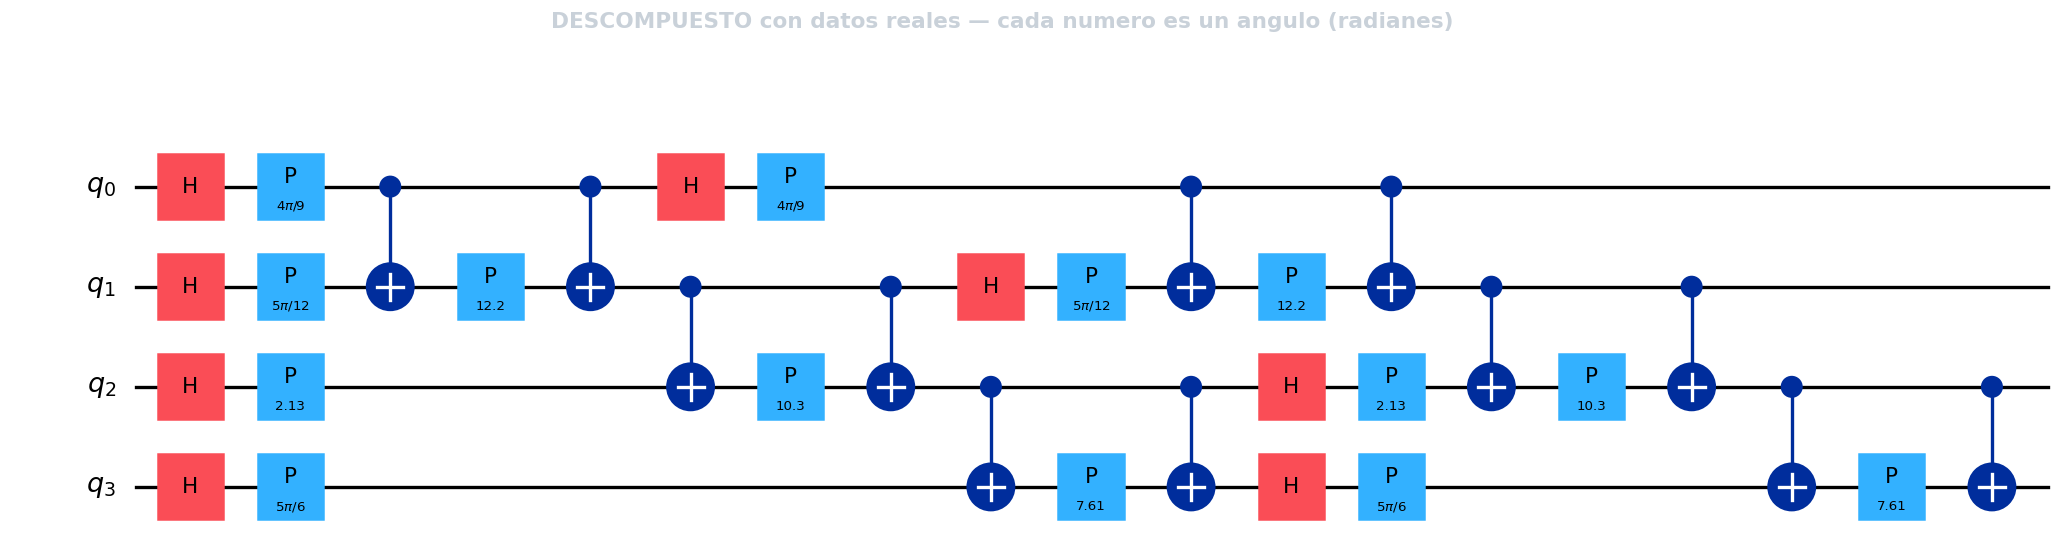


  Los 4 valores [0.70, 0.65, 1.06, 1.31] ahora son
  angulos de rotacion en las puertas de fase del circuito cuantico.

  MATRICES CUANTICAS RESULTANTES (Con Datos Reales de Iris)
Relacion de Entrada a Qubits:
  El dato x[0] con valor 0.6981 modifica la fase del qubit q0
  El dato x[1] con valor 0.6545 modifica la fase del qubit q1
  El dato x[2] con valor 1.0649 modifica la fase del qubit q2
  El dato x[3] con valor 1.3090 modifica la fase del qubit q3

=== VECTOR DE ESTADO (Dataset Iris - Fila 0) ===
-> Dimension (Shape): (16,) -> Corresponde a 16 posibles estados de superposicion.
-> (Mostrando solo los primeros 4 elementos para no saturar pantalla):
[0.055-0.036j 0.04 -0.143j 0.133+0.206j 0.075+0.233j]

=== MATRIZ UNITARIA (Dataset Iris - Fila 0) ===
-> Dimension (Shape): (16, 16) -> Es una matriz de 16x16.
-> (Mostrando solo un extracto de 4x4 de la esquina superior izquierda):
[[ 0.055-0.036j -0.097-0.112j -0.17 +0.176j  0.173+0.174j]
 [ 0.04 -0.143j  0.061+0.026j -0.049+0.24j  

In [75]:
from IPython.display import display
# ============================================================
# CELDA VIS-5: COMO LOS DATOS REALES SE CODIFICAN EN EL CIRCUITO
# ============================================================

print("=" * 70)
print("  CODIFICACION: Del vector clasico al circuito cuantico")
print("=" * 70)

sample = X_tr_hw[0]
label = y_tr_hw[0]

print(f"\n  Muestra: X_tr_hw[0]  Clase: {label} ({iris.target_names[label]})")
print(f"  Datos [0, pi]: [{', '.join(f'{v:.4f}' for v in sample)}]")
print(f"\n  Cada valor se convierte en un ANGULO DE ROTACION:")
for i, v in enumerate(sample):
    g = np.degrees(v)
    print(f"    x{i} = {v:.4f} rad = {g:6.1f} grados -> Fase del qubit q{i}")

fm_demo = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
params = list(fm_demo.parameters)
param_dict = dict(zip(params, sample))

# Grafico 1: parametros simbolicos
fig1 = fm_demo.draw('mpl', fold=30)
fig1.set_size_inches(18, 4)
fig1.suptitle('ANTES: ZZFeatureMap con parametros SIMBOLICOS (x[0], x[1], x[2], x[3])', fontweight='bold', fontsize=13, y=1.02)
display(fig1)

# Grafico 2: datos reales
fm_bound = fm_demo.assign_parameters(param_dict)
fig2 = fm_bound.draw('mpl', fold=30)
fig2.set_size_inches(18, 4)
fig2.suptitle(f'DESPUES: ZZFeatureMap con datos REALES de Iris (clase {iris.target_names[label]})', fontweight='bold', fontsize=13, y=1.02)
display(fig2)

# Grafico 3: descompuesto con datos
fig3 = fm_bound.decompose().draw('mpl', fold=30)
fig3.set_size_inches(22, 5)
fig3.suptitle(f'DESCOMPUESTO con datos reales — cada numero es un angulo (radianes)', fontweight='bold', fontsize=13, y=1.02)
display(fig3)

print(f"\n  Los 4 valores [{', '.join(f'{v:.2f}' for v in sample)}] ahora son")
print(f"  angulos de rotacion en las puertas de fase del circuito cuantico.")

# --- AÑADIDO: MATRICES CON DATOS REALES ---
from qiskit.quantum_info import Operator, Statevector

print("\n" + "=" * 70)
print("  MATRICES CUANTICAS RESULTANTES (Con Datos Reales de Iris)")
print("=" * 70)

print("Relacion de Entrada a Qubits:")
for i, val in enumerate(sample):
    print(f"  El dato x[{i}] con valor {val:.4f} modifica la fase del qubit q{i}")

vector_estado = Statevector.from_instruction(fm_bound)
print("\n=== VECTOR DE ESTADO (Dataset Iris - Fila 0) ===")
print(f"-> Dimension (Shape): {vector_estado.data.shape} -> Corresponde a {2**fm_bound.num_qubits} posibles estados de superposicion.")
print("-> (Mostrando solo los primeros 4 elementos para no saturar pantalla):")
print(np.round(vector_estado.data[:4], 3))

matriz_unitaria = Operator(fm_bound)
print("\n=== MATRIZ UNITARIA (Dataset Iris - Fila 0) ===")
print(f"-> Dimension (Shape): {matriz_unitaria.data.shape} -> Es una matriz de {2**fm_bound.num_qubits}x{2**fm_bound.num_qubits}.")
print("-> (Mostrando solo un extracto de 4x4 de la esquina superior izquierda):")
print(np.round(matriz_unitaria.data[:4, :4], 3))


  CIRCUITO 4: Compute-Uncompute (Kernel Cuantico)

  Comparando dos muestras:
  Muestra i (clase 1): [0.6981, 0.6545, 1.0649, 1.3090]
  Muestra j (clase 1): [1.6581, 0.2618, 1.8637, 1.8326]

  Formula: K(xi, xj) = |<0n| U+(xj) * U(xi) |0n>|^2 = P(|0000>)


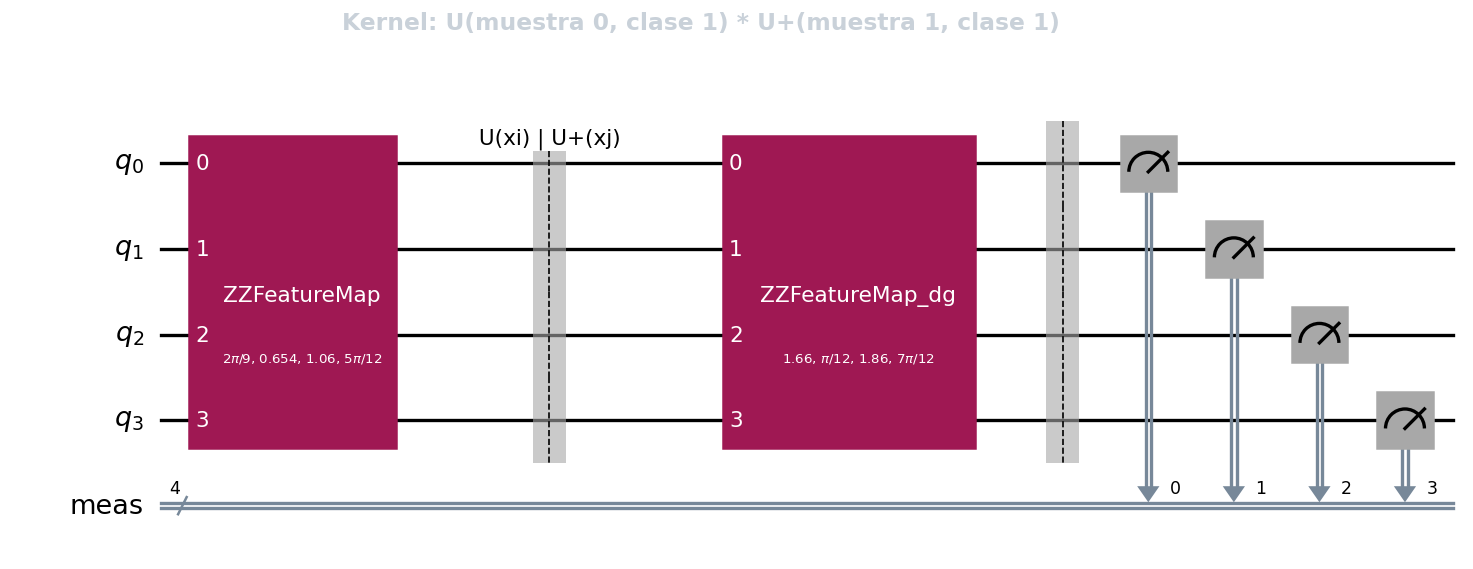

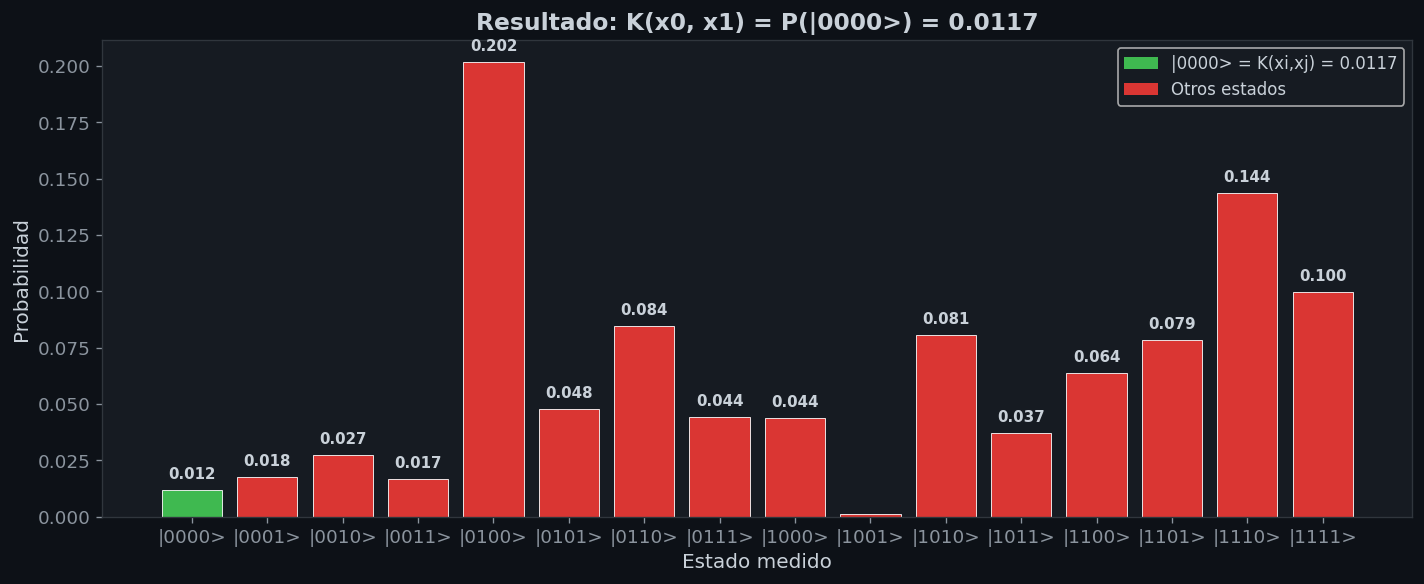


  RESULTADOS:
  K(x0, x1) = 0.0117  (muestras DIFERENTES, clase 1 vs 1)
  K(x0, x0) = 1.0000  (muestra consigo MISMA -> ~1.0)

  Para el experimento completo:
  Kernel train: 13x13 = 169 circuitos
  Kernel test:  9x13 = 117 circuitos
  Total: 286 circuitos x 2048 shots


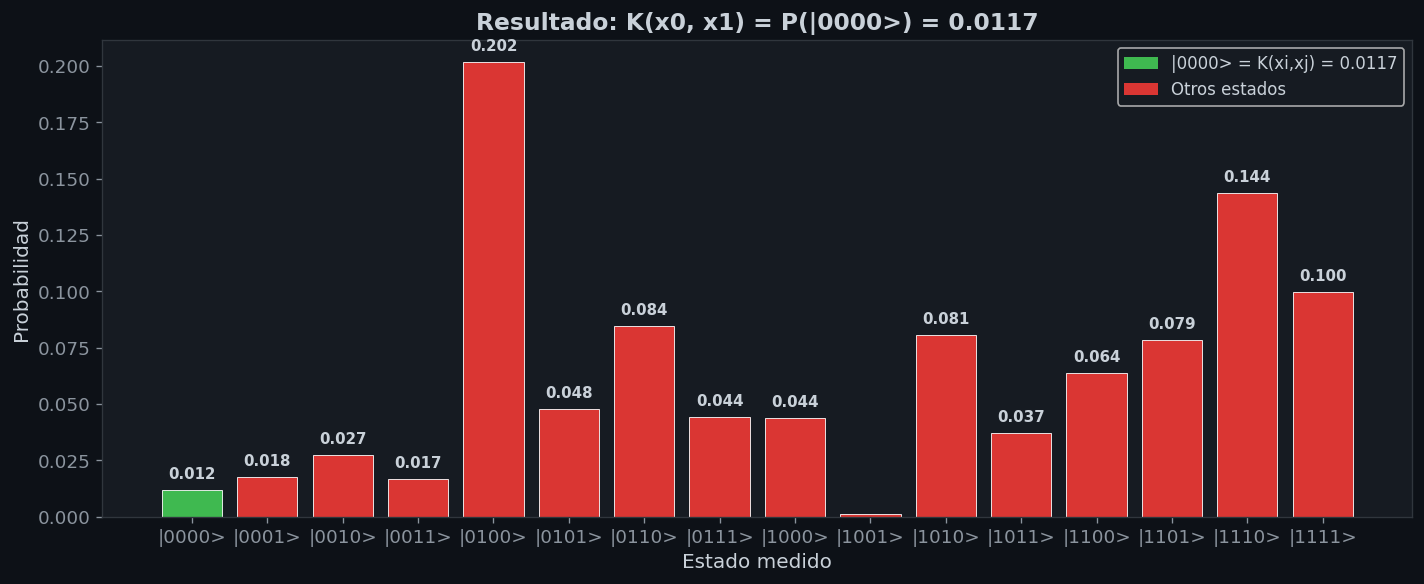

In [76]:
from IPython.display import display
# ============================================================
# CELDA VIS-6: CIRCUITO COMPUTE-UNCOMPUTE (Kernel Cuantico)
# ============================================================
# K(xi, xj) = |<0n| U+(xj) * U(xi) |0n>|^2 = P(|0000>)
# ============================================================

print("=" * 70)
print("  CIRCUITO 4: Compute-Uncompute (Kernel Cuantico)")
print("=" * 70)

x_i, x_j = X_tr_hw[0], X_tr_hw[1]
y_i, y_j = int(y_tr_hw[0]), int(y_tr_hw[1])

print(f"\n  Comparando dos muestras:")
print(f"  Muestra i (clase {y_i}): [{', '.join(f'{v:.4f}' for v in x_i)}]")
print(f"  Muestra j (clase {y_j}): [{', '.join(f'{v:.4f}' for v in x_j)}]")
print(f"\n  Formula: K(xi, xj) = |<0n| U+(xj) * U(xi) |0n>|^2 = P(|0000>)")

fm_kernel = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
params_k = list(fm_kernel.parameters)

fm_i = fm_kernel.assign_parameters(dict(zip(params_k, x_i)))
fm_j_inv = fm_kernel.assign_parameters(dict(zip(params_k, x_j))).inverse()

kernel_circ = QuantumCircuit(4)
kernel_circ.compose(fm_i, inplace=True)
kernel_circ.barrier(label=' U(xi) | U+(xj) ')
kernel_circ.compose(fm_j_inv, inplace=True)
kernel_circ.measure_all()

# Grafico 1: circuito kernel completo
fig1 = kernel_circ.draw('mpl', fold=30)
fig1.set_size_inches(24, 5)
fig1.suptitle(f'Kernel: U(muestra 0, clase {y_i}) * U+(muestra 1, clase {y_j})', fontweight='bold', fontsize=14, y=1.02)
display(fig1)

# Simular
sim_k = StatevectorSampler(seed=SEED)
job_k = sim_k.run([kernel_circ], shots=SHOTS)
counts_k = job_k.result()[0].data.meas.get_counts()
total_k = sum(counts_k.values())
zero_state = '0' * 4
p_zero = counts_k.get(zero_state, 0) / total_k

# K(x,x)
fm_self = fm_kernel.assign_parameters(dict(zip(params_k, x_i)))
fm_self_inv = fm_kernel.assign_parameters(dict(zip(params_k, x_i))).inverse()
self_circ = QuantumCircuit(4)
self_circ.compose(fm_self, inplace=True)
self_circ.compose(fm_self_inv, inplace=True)
self_circ.measure_all()
job_self = sim_k.run([self_circ], shots=SHOTS)
counts_self = job_self.result()[0].data.meas.get_counts()
p_self = counts_self.get(zero_state, 0) / sum(counts_self.values())

# Grafico 2: histograma de resultados
from matplotlib.patches import Patch
fig2, ax_h = plt.subplots(figsize=(12, 5))
states = sorted(counts_k.keys())
probs = [counts_k[s] / total_k for s in states]
colors_h = ['#3fb950' if s == zero_state else '#da3633' for s in states]
bars = ax_h.bar([f'|{s}>' for s in states], probs, color=colors_h, edgecolor='white', linewidth=0.5)
ax_h.set_ylabel('Probabilidad', fontsize=12)
ax_h.set_xlabel('Estado medido', fontsize=12)
ax_h.set_title(f'Resultado: K(x0, x1) = P(|0000>) = {p_zero:.4f}', fontweight='bold', fontsize=14)
for bar, p in zip(bars, probs):
    if p > 0.005:
        ax_h.text(bar.get_x() + bar.get_width()/2, p + 0.005, f'{p:.3f}', ha='center', fontsize=9, fontweight='bold')
ax_h.legend(handles=[
    Patch(facecolor='#3fb950', label=f'|0000> = K(xi,xj) = {p_zero:.4f}'),
    Patch(facecolor='#da3633', label='Otros estados')
], fontsize=10, loc='upper right')
plt.tight_layout()
display(fig2)

print(f"\n  RESULTADOS:")
print(f"  K(x0, x1) = {p_zero:.4f}  (muestras DIFERENTES, clase {y_i} vs {y_j})")
print(f"  K(x0, x0) = {p_self:.4f}  (muestra consigo MISMA -> ~1.0)")
print(f"\n  Para el experimento completo:")
print(f"  Kernel train: {N_TRAIN_HW}x{N_TRAIN_HW} = {N_TRAIN_HW**2} circuitos")
print(f"  Kernel test:  {N_TEST_HW}x{N_TRAIN_HW} = {N_TEST_HW*N_TRAIN_HW} circuitos")
print(f"  Total: {N_TRAIN_HW**2 + N_TEST_HW*N_TRAIN_HW} circuitos x {SHOTS} shots")


---
## 🧪 Sección 2: Experimento 1 — Baseline en Simulador
> **QPU:** 0 min (todo local)  
> Corrige el VQC de la Primera Parte (37.78% → esperamos 80%+) y establece baselines clásicos.

In [77]:
# ============================================================
# CELDA 2A: BASELINES CLÁSICOS
# ============================================================
print(' Modelos clásicos...')

# SVM-RBF
t0 = time.time()
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
svm.fit(X_tr, y_tr)
t_svm = time.time() - t0
y_pred_svm = svm.predict(X_te)
acc_svm = accuracy_score(y_te, y_pred_svm)
f1_svm = f1_score(y_te, y_pred_svm, average='macro')
print(f'   SVM-RBF:  Acc={acc_svm:.4f}  F1={f1_svm:.4f}')

# MLP
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=SEED)
mlp.fit(X_tr, y_tr)
t_mlp = time.time() - t0
y_pred_mlp = mlp.predict(X_te)
acc_mlp = accuracy_score(y_te, y_pred_mlp)
f1_mlp = f1_score(y_te, y_pred_mlp, average='macro')
print(f'   MLP:      Acc={acc_mlp:.4f}  F1={f1_mlp:.4f}')

# KNN
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)
t_knn = time.time() - t0
y_pred_knn = knn.predict(X_te)
acc_knn = accuracy_score(y_te, y_pred_knn)
f1_knn = f1_score(y_te, y_pred_knn, average='macro')
print(f'   KNN:      Acc={acc_knn:.4f}  F1={f1_knn:.4f}')

resultados_globales['SVM-RBF'] = {'accuracy': acc_svm, 'f1': f1_svm, 'tiempo': t_svm, 'entorno': 'Clásico'}
resultados_globales['MLP'] = {'accuracy': acc_mlp, 'f1': f1_mlp, 'tiempo': t_mlp, 'entorno': 'Clásico'}
resultados_globales['KNN'] = {'accuracy': acc_knn, 'f1': f1_knn, 'tiempo': t_knn, 'entorno': 'Clásico'}

 Modelos clásicos...
   SVM-RBF:  Acc=0.9333  F1=0.9333
   MLP:      Acc=0.9333  F1=0.9333
   KNN:      Acc=0.9333  F1=0.9327


In [78]:
# ============================================================
# CELDA 2B: VQC CORREGIDO (3 semillas — 300 iteraciones)
# ============================================================
print("=" * 70)
print("  [SIM] EXPERIMENTO 1 — VQC (Variational Quantum Classifier)")
print("=" * 70)
print("  DATOS DE ENTRADA:")
print(f"    X_tr:  {X_tr.shape}  ->  {X_tr.shape[0]} muestras x {X_tr.shape[1]} caracteristicas")
print(f"    X_te:  {X_te.shape}")
print(f"    Clases (train): {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"    Muestra fila 0: {np.round(X_tr[0], 4)}")
print(f"    Rango valores:  [{X_tr.min():.4f}, {X_tr.max():.4f}] (escalado [0, pi])")
print()
print("  ARQUITECTURA:")
print("    Feature map: ZZFeatureMap  (4 qubits, reps=2, linear)")
print("    Ansatz:      RealAmplitudes (4 qubits, reps=3, linear)")
print("    Optimizador: COBYLA  maxiter=300")
print("    Semillas:    [42, 123, 789]")
print("=" * 70)

vqc_accuracies = []
vqc_losses_all = []
best_vqc_acc = 0
best_vqc_model = None

seeds = [42, 123, 789]

for i, seed in enumerate(seeds):
    np.random.seed(seed)
    fm = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    ans = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')

    hist = {'loss': []}
    def callback(weights, loss, *args):
        hist['loss'].append(loss)
        it = len(hist['loss'])
        if it == 1 or it % 25 == 0:
            print(f"      iter {it:3d} | loss = {loss:.6f}")

    print(f"\n  Semilla {seed} ({i+1}/3):")
    t0 = time.time()
    vqc = VQC(
        feature_map=fm, ansatz=ans, loss='cross_entropy',
        optimizer=COBYLA(maxiter=300),
        sampler=StatevectorSampler(), callback=callback,
    )
    vqc.fit(X_tr, y_tr_oh)
    t_elapsed = time.time() - t0
    acc = vqc.score(X_te, y_te_oh)

    vqc_accuracies.append(acc)
    vqc_losses_all.append(hist['loss'])
    print(f"    Resultado semilla {seed}: Acc={acc:.4f}  iteraciones={len(hist['loss'])}  tiempo={t_elapsed:.1f}s")
    print(f"    Loss inicial={hist['loss'][0]:.6f}  ->  Loss final={hist['loss'][-1]:.6f}")

    if acc > best_vqc_acc:
        best_vqc_acc = acc
        best_vqc_model = vqc
        best_vqc_loss = hist['loss']
        best_vqc_time = t_elapsed

vqc_mean = np.mean(vqc_accuracies)
vqc_std  = np.std(vqc_accuracies)

y_pred_vqc_raw = best_vqc_model.predict(X_te)
y_pred_vqc = y_pred_vqc_raw.argmax(axis=1) if y_pred_vqc_raw.ndim > 1 else y_pred_vqc_raw
f1_vqc = f1_score(y_te, y_pred_vqc, average='macro')

print()
print("=" * 70)
print("  RESULTADO FINAL — VQC")
print("=" * 70)
print(f"  Accuracy por semilla: {[round(a,4) for a in vqc_accuracies]}")
print(f"  Media +/- std:        {vqc_mean:.4f} +/- {vqc_std:.4f}")
print(f"  Mejor accuracy:       {best_vqc_acc:.4f}")
print(f"  F1-score (macro):     {f1_vqc:.4f}")
print(f"  Tiempo mejor modelo:  {best_vqc_time:.1f}s")
print("=" * 70)

resultados_globales['VQC (Simulador)'] = {
    'accuracy': best_vqc_acc, 'f1': f1_vqc,
    'tiempo': best_vqc_time, 'entorno': 'Simulador',
    'nota': f'{vqc_mean:.4f}+/-{vqc_std:.4f} (3 seeds)'
}


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  [SIM] EXPERIMENTO 1 — VQC (Variational Quantum Classifier)
  DATOS DE ENTRADA:
    X_tr:  (105, 4)  ->  105 muestras x 4 caracteristicas
    X_te:  (45, 4)
    Clases (train): {np.int64(0): np.int64(35), np.int64(1): np.int64(35), np.int64(2): np.int64(35)}
    Muestra fila 0: [0.6981 0.6545 1.0649 1.309 ]
    Rango valores:  [0.0000, 3.1416] (escalado [0, pi])

  ARQUITECTURA:
    Feature map: ZZFeatureMap  (4 qubits, reps=2, linear)
    Ansatz:      RealAmplitudes (4 qubits, reps=3, linear)
    Optimizador: COBYLA  maxiter=300
    Semillas:    [42, 123, 789]

  Semilla 42 (1/3):
      iter   1 | loss = 11.874884
      iter  25 | loss = 11.714138
      iter  50 | loss = 11.647172
      iter  75 | loss = 11.650058
      iter 100 | loss = 11.650968
      iter 125 | loss = 11.645189


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


    Resultado semilla 42: Acc=0.4000  iteraciones=136  tiempo=36.2s
    Loss inicial=11.874884  ->  Loss final=11.640943

  Semilla 123 (2/3):
      iter   1 | loss = 11.902689
      iter  25 | loss = 11.701916
      iter  50 | loss = 11.549688
      iter  75 | loss = 11.516699
      iter 100 | loss = 11.520413
      iter 125 | loss = 11.524572
      iter 150 | loss = 11.517170


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


    Resultado semilla 123: Acc=0.5333  iteraciones=170  tiempo=46.5s
    Loss inicial=11.902689  ->  Loss final=11.518891

  Semilla 789 (3/3):
      iter   1 | loss = 11.937967
      iter  25 | loss = 11.769738
      iter  50 | loss = 11.643509
      iter  75 | loss = 11.625620
      iter 100 | loss = 11.621751
      iter 125 | loss = 11.618748
      iter 150 | loss = 11.618560
    Resultado semilla 789: Acc=0.4889  iteraciones=167  tiempo=40.6s
    Loss inicial=11.937967  ->  Loss final=11.624750

  RESULTADO FINAL — VQC
  Accuracy por semilla: [0.4, 0.5333, 0.4889]
  Media +/- std:        0.4741 +/- 0.0554
  Mejor accuracy:       0.5333
  F1-score (macro):     0.4448
  Tiempo mejor modelo:  46.5s


In [79]:
# ============================================================
# CELDA 2C: QSVC EN SIMULADOR (dataset completo)
# ============================================================
print("=" * 70)
print("  [SIM] EXPERIMENTO 1 — QSVC Simulador (dataset completo)")
print("=" * 70)
print("  DATOS DE ENTRADA:")
print(f"    X_tr:  {X_tr.shape}  ->  {X_tr.shape[0]} muestras x {X_tr.shape[1]} caracteristicas")
print(f"    X_te:  {X_te.shape}")
print(f"    Kernel esperado train: ({X_tr.shape[0]} x {X_tr.shape[0]})")
print(f"    Kernel esperado test:  ({X_te.shape[0]} x {X_tr.shape[0]})")

fm_qsvc = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_sim_full = FidelityQuantumKernel(feature_map=fm_qsvc)

print("\n  Calculando matrices de kernel cuantico...")
t0 = time.time()
K_train_sim_full = kernel_sim_full.evaluate(X_tr)
K_test_sim_full  = kernel_sim_full.evaluate(X_te, X_tr)
t_qsvc_sim = time.time() - t0

print(f"    K_train shape: {K_train_sim_full.shape}  diagonal media: {np.diag(K_train_sim_full).mean():.4f}")
print(f"    K_test  shape: {K_test_sim_full.shape}")
print(f"    K_train [0:3, 0:3] (muestra):")
print(np.round(K_train_sim_full[:3, :3], 4))
print(f"    Tiempo calculo kernel: {t_qsvc_sim:.2f}s")

svc_q_sim = SVC(kernel='precomputed', C=1.0)
svc_q_sim.fit(K_train_sim_full, y_tr)
y_pred_qsvc_sim = svc_q_sim.predict(K_test_sim_full)
acc_qsvc_sim = accuracy_score(y_te, y_pred_qsvc_sim)
f1_qsvc_sim  = f1_score(y_te, y_pred_qsvc_sim, average='macro')

print()
print("=" * 70)
print("  RESULTADO FINAL — QSVC Simulador")
print("=" * 70)
print(f"  Accuracy:   {acc_qsvc_sim:.4f}")
print(f"  F1 (macro): {f1_qsvc_sim:.4f}")
print(f"  Tiempo:     {t_qsvc_sim:.2f}s")
print("=" * 70)

resultados_globales['QSVC (Simulador)'] = {
    'accuracy': acc_qsvc_sim, 'f1': f1_qsvc_sim,
    'tiempo': t_qsvc_sim, 'entorno': 'Simulador'
}


  [SIM] EXPERIMENTO 1 — QSVC Simulador (dataset completo)
  DATOS DE ENTRADA:
    X_tr:  (105, 4)  ->  105 muestras x 4 caracteristicas
    X_te:  (45, 4)
    Kernel esperado train: (105 x 105)
    Kernel esperado test:  (45 x 105)

  Calculando matrices de kernel cuantico...
    K_train shape: (105, 105)  diagonal media: 1.0000
    K_test  shape: (45, 105)
    K_train [0:3, 0:3] (muestra):
[[1.     0.0145 0.111 ]
 [0.0145 1.     0.0058]
 [0.111  0.0058 1.    ]]
    Tiempo calculo kernel: 19.38s

  RESULTADO FINAL — QSVC Simulador
  Accuracy:   0.7778
  F1 (macro): 0.7772
  Tiempo:     19.38s


In [80]:
# ============================================================
# CELDA 2D: QSVC SIMULADOR (subset HW — referencia justa)
# ============================================================
print("=" * 70)
print("  [SIM] EXPERIMENTO 1 — QSVC Simulador (subset para comparacion con HW)")
print("=" * 70)
print("  DATOS DE ENTRADA (subset igual al hardware):")
print(f"    X_tr_hw:  {X_tr_hw.shape}  ->  {X_tr_hw.shape[0]} muestras x {X_tr_hw.shape[1]} caracteristicas")
print(f"    X_te_hw:  {X_te_hw.shape}")
print(f"    Kernel esperado train: ({X_tr_hw.shape[0]} x {X_tr_hw.shape[0]})")
print(f"    Kernel esperado test:  ({X_te_hw.shape[0]} x {X_tr_hw.shape[0]})")
print(f"    Muestra fila 0 (train): {np.round(X_tr_hw[0], 4)}")

fm_sim_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_sim_hw_obj = FidelityQuantumKernel(feature_map=fm_sim_hw)

print("\n  Calculando matrices de kernel cuantico...")
t0 = time.time()
K_train_sim_hw = kernel_sim_hw_obj.evaluate(X_tr_hw)
K_test_sim_hw  = kernel_sim_hw_obj.evaluate(X_te_hw, X_tr_hw)
t_sim_hw = time.time() - t0

print(f"    K_train shape: {K_train_sim_hw.shape}")
print(f"    K_test  shape: {K_test_sim_hw.shape}")
print(f"    K_train [0:3, 0:3] (muestra):")
print(np.round(K_train_sim_hw[:3, :3], 4))
print(f"    Tiempo calculo kernel: {t_sim_hw:.2f}s")

svc_sim_hw = SVC(kernel='precomputed', C=1.0)
svc_sim_hw.fit(K_train_sim_hw, y_tr_hw)
y_pred_sim_hw = svc_sim_hw.predict(K_test_sim_hw)
acc_sim_hw = accuracy_score(y_te_hw, y_pred_sim_hw)
f1_sim_hw  = f1_score(y_te_hw, y_pred_sim_hw, average='macro')

guardar_checkpoint(CK_SIM_IRIS, {
    'K_train': K_train_sim_hw, 'K_test': K_test_sim_hw,
    'acc': np.array(acc_sim_hw), 'f1': np.array(f1_sim_hw)
})

print()
print("=" * 70)
print("  RESULTADO FINAL — QSVC Simulador (subset)")
print("=" * 70)
print(f"  Accuracy:   {acc_sim_hw:.4f}")
print(f"  F1 (macro): {f1_sim_hw:.4f}")
print(f"  Tiempo:     {t_sim_hw:.2f}s")
print("  [SIM vs HW REAL] Esta es la referencia simulada perfecta para medir el ruido del hardware")
print("=" * 70)


  [SIM] EXPERIMENTO 1 — QSVC Simulador (subset para comparacion con HW)
  DATOS DE ENTRADA (subset igual al hardware):
    X_tr_hw:  (13, 4)  ->  13 muestras x 4 caracteristicas
    X_te_hw:  (9, 4)
    Kernel esperado train: (13 x 13)
    Kernel esperado test:  (9 x 13)
    Muestra fila 0 (train): [0.6981 0.6545 1.0649 1.309 ]

  Calculando matrices de kernel cuantico...
    K_train shape: (13, 13)
    K_test  shape: (9, 13)
    K_train [0:3, 0:3] (muestra):
[[1.     0.0145 0.111 ]
 [0.0145 1.     0.0058]
 [0.111  0.0058 1.    ]]
    Tiempo calculo kernel: 0.38s
    Checkpoint guardado: checkpoints\kernel_sim_iris_n13m9.npz

  RESULTADO FINAL — QSVC Simulador (subset)
  Accuracy:   0.3333
  F1 (macro): 0.3238
  Tiempo:     0.38s
  [SIM vs HW REAL] Esta es la referencia simulada perfecta para medir el ruido del hardware


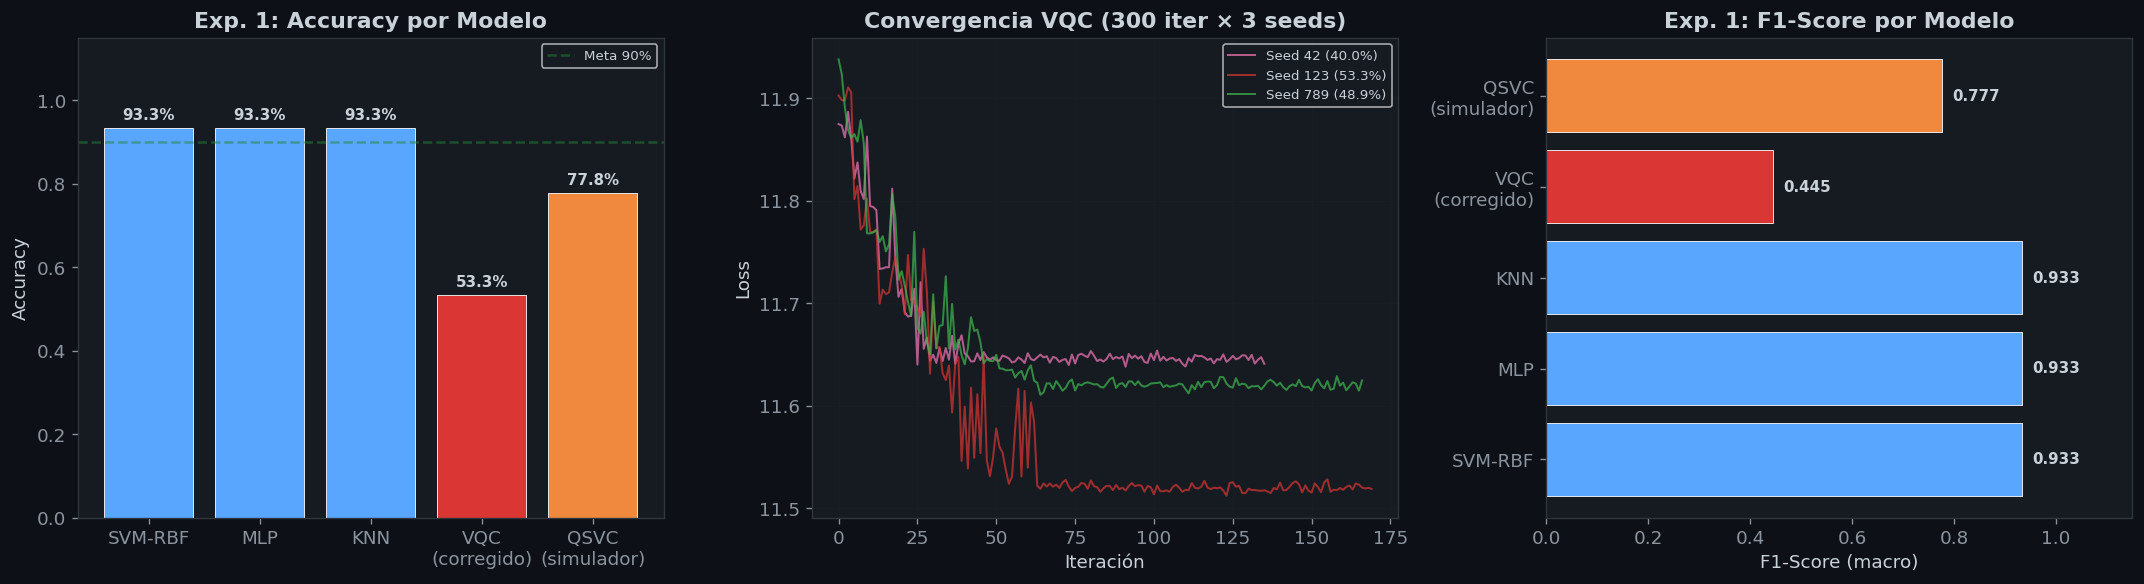

📋 Exp. 1 completado y guardado.


In [81]:
# ============================================================
# CELDA 2E: GRÁFICOS EXPERIMENTO 1
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras accuracy
modelos = ['SVM-RBF', 'MLP', 'KNN', 'VQC\n(corregido)', 'QSVC\n(simulador)']
accs = [acc_svm, acc_mlp, acc_knn, best_vqc_acc, acc_qsvc_sim]
colores = ['#58a6ff', '#58a6ff', '#58a6ff', '#da3633', '#f0883e']

bars = axes[0].bar(modelos, accs, color=colores, edgecolor='white', linewidth=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 1: Accuracy por Modelo', fontweight='bold')
axes[0].axhline(y=0.9, color='#238636', linestyle='--', alpha=0.5, label='Meta 90%')
axes[0].legend(fontsize=8)
for bar, a in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=9)

# Curvas de pérdida VQC
colors_s = ['#f778ba', '#da3633', '#3fb950']
for j, (loss, seed) in enumerate(zip(vqc_losses_all, seeds)):
    axes[1].plot(loss, color=colors_s[j], alpha=0.7, linewidth=1.2, label=f'Seed {seed} ({vqc_accuracies[j]:.1%})')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Loss')
axes[1].set_title('Convergencia VQC (300 iter × 3 seeds)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# F1 comparativo
f1s = [f1_svm, f1_mlp, f1_knn, f1_vqc, f1_qsvc_sim]
bars2 = axes[2].barh(modelos, f1s, color=colores, edgecolor='white', linewidth=0.5)
axes[2].set_xlim(0, 1.15)
axes[2].set_xlabel('F1-Score (macro)')
axes[2].set_title('Exp. 1: F1-Score por Modelo', fontweight='bold')
for bar, f in zip(bars2, f1s):
    axes[2].text(f+0.02, bar.get_y()+bar.get_height()/2, f'{f:.3f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('exp1_baseline_corregido.png', dpi=150, bbox_inches='tight')
plt.show()
print('📋 Exp. 1 completado y guardado.')

---
##  Sección 3: Experimento 2 — Estado de Bell en Hardware Real
> **QPU:** ~3 segundos (1 circuito simple)  
> Valida la pipeline de ejecución en el QPU con el estado:
> $$\Phi^+\rangle = \frac{1}{\sqrt{2}}(00\rangle + 11\rangle)$$

 Circuito de Bell:


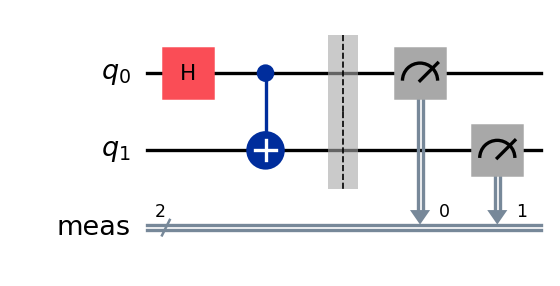


 Simulador (2048 shots):
   00⟩: 0.5054
   11⟩: 0.4946


In [82]:
from IPython.display import display
# ============================================================
# CELDA 3A: ESTADO DE BELL — SIMULADOR
# ============================================================
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

print(' Circuito de Bell:')
display(bell.draw('mpl'))

# Simulador ideal
sim_sampler = StatevectorSampler(seed=SEED)
sim_job = sim_sampler.run([bell], shots=SHOTS)
sim_result = sim_job.result()
sim_counts = sim_result[0].data.meas.get_counts()
total_sim = sum(sim_counts.values())
sim_probs = {k: v/total_sim for k, v in sim_counts.items()}

print(f'\n Simulador ({SHOTS} shots):')
for s, p in sorted(sim_probs.items()):
    print(f'   {s}⟩: {p:.4f}')

  ANALISIS DEL ESTADO DE BELL

  Qubits:      2
  Profundidad: 3
  Puertas:     {'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}


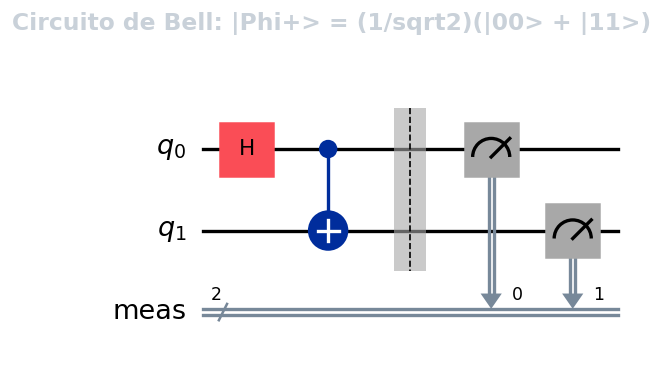


  Evolucion del estado:
  |00> -- H en q0 --> (1/sqrt2)(|00> + |10>)
       -- CNOT    --> (1/sqrt2)(|00> + |11>) = |Phi+>
       -> Estado de MAXIMO ENTRELAZAMIENTO


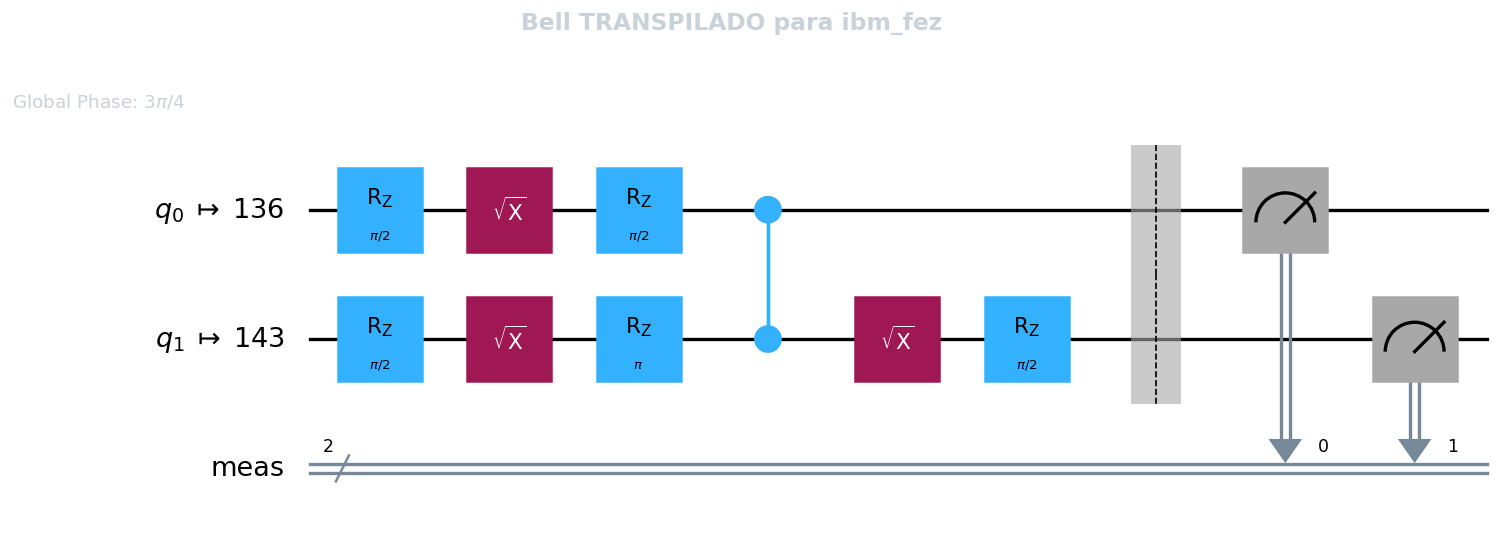


  Profundidad transpilada: 7
  Puertas nativas:        {'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}


<Figure size 768x576 with 0 Axes>

In [83]:
from IPython.display import display
# ============================================================
# CELDA 3A-VIS: ANALISIS DEL CIRCUITO DE BELL
# ============================================================

print("=" * 70)
print("  ANALISIS DEL ESTADO DE BELL")
print("=" * 70)

print(f"\n  Qubits:      {bell.num_qubits}")
print(f"  Profundidad: {bell.depth()}")
print(f"  Puertas:     {dict(bell.count_ops())}")

# Grafico: circuito original
fig_b = bell.draw('mpl')
fig_b.set_size_inches(8, 3)
fig_b.suptitle('Circuito de Bell: |Phi+> = (1/sqrt2)(|00> + |11>)', fontweight='bold', fontsize=14, y=1.08)
plt.tight_layout()
display(fig_b)

print(f"\n  Evolucion del estado:")
print(f"  |00> -- H en q0 --> (1/sqrt2)(|00> + |10>)")
print(f"       -- CNOT    --> (1/sqrt2)(|00> + |11>) = |Phi+>")
print(f"       -> Estado de MAXIMO ENTRELAZAMIENTO")

# Transpilacion (requiere conexion a IBM)
try:
    pm_bell = generate_preset_pass_manager(backend=backend, optimization_level=3)
    bell_transpiled = pm_bell.run(bell)
    fig_bt = bell_transpiled.draw('mpl', idle_wires=False, fold=30)
    fig_bt.set_size_inches(16, 5)
    fig_bt.suptitle(f'Bell TRANSPILADO para {backend.name}', fontweight='bold', fontsize=14, y=1.02)
    display(fig_bt)
    print(f"\n  Profundidad transpilada: {bell_transpiled.depth()}")
    print(f"  Puertas nativas:        {dict(bell_transpiled.count_ops())}")
except:
    print("\n  [Ejecuta la celda de conexion IBM primero para ver el transpilado]")


In [84]:
# ============================================================
# CELDA 3B: ESTADO DE BELL — HARDWARE REAL (~3s QPU)
# ============================================================

if existe_checkpoint('bell_hw'):
    ck = cargar_checkpoint('bell_hw')
    hw_probs = dict(ck['hw_probs'].item())
    fidelity_bell = float(ck['fidelity'])
    print(f' Bell cargado desde checkpoint. Fidelidad: {fidelity_bell:.4f}')
else:
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    bell_isa = pm.run(bell)
    print(f' Transpilado: prof. {bell.depth()} → {bell_isa.depth()}')

    print(f' Enviando a {backend.name}...')
    hw_sampler = SamplerV2(mode=backend)
    hw_job = hw_sampler.run([bell_isa], shots=SHOTS)
    print(f'   Job: {hw_job.job_id()}   Esperando...')

    hw_result = hw_job.result()
    hw_counts = hw_result[0].data.meas.get_counts()
    total_hw = sum(hw_counts.values())
    hw_probs = {k: v/total_hw for k, v in hw_counts.items()}

    # Fidelidad Bhattacharyya
    all_states = sorted(set(list(sim_probs.keys()) + list(hw_probs.keys())))
    fidelity_bell = sum(
        np.sqrt(sim_probs.get(s, 0) * hw_probs.get(s, 0)) for s in all_states
    ) ** 2

    guardar_checkpoint('bell_hw', {
        'hw_probs': np.array(hw_probs, dtype=object),
        'fidelity': np.array(fidelity_bell)
    })

# Mostrar resultados
print(f'\n Hardware Real — {backend.name}:')
for s in ['00', '01', '10', '11']:
    p_s = sim_probs.get(s, 0)
    p_h = hw_probs.get(s, 0)
    print(f'   {s}⟩: Ideal={p_s:.4f}  HW={p_h:.4f}  Δ={abs(p_h-p_s):.4f}')
print(f'\n Fidelidad: {fidelity_bell:.4f}')

    Checkpoint cargado:  checkpoints\bell_hw.npz
 Bell cargado desde checkpoint. Fidelidad: 0.9834

 Hardware Real — ibm_fez:
   00⟩: Ideal=0.5054  HW=0.4971  Δ=0.0083
   01⟩: Ideal=0.0000  HW=0.0073  Δ=0.0073
   10⟩: Ideal=0.0000  HW=0.0093  Δ=0.0093
   11⟩: Ideal=0.4946  HW=0.4863  Δ=0.0083

 Fidelidad: 0.9834


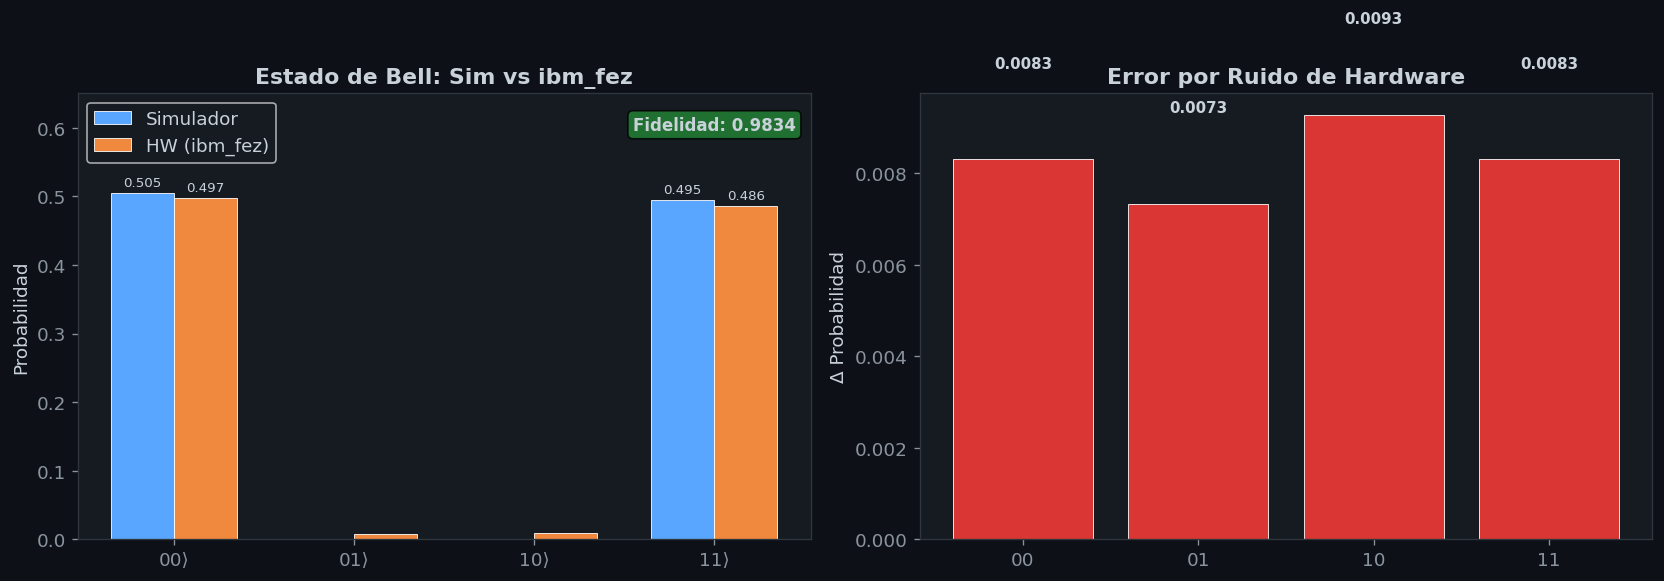

In [85]:
# ============================================================
# CELDA 3C: GRÁFICO BELL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
states = ['00', '01', '10', '11']
probs_s = [sim_probs.get(s, 0) for s in states]
probs_h = [hw_probs.get(s, 0) for s in states]

x = np.arange(len(states))
w = 0.35
b1 = axes[0].bar(x-w/2, probs_s, w, label='Simulador', color='#58a6ff', edgecolor='white', linewidth=0.5)
b2 = axes[0].bar(x+w/2, probs_h, w, label=f'HW ({backend.name})', color='#f0883e', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{s}⟩' for s in states])
axes[0].set_ylabel('Probabilidad')
axes[0].set_title(f'Estado de Bell: Sim vs {backend.name}', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 0.65)
for bar, p in zip(b1, probs_s):
    if p > 0.01: axes[0].text(bar.get_x()+bar.get_width()/2, p+0.01, f'{p:.3f}', ha='center', fontsize=8)
for bar, p in zip(b2, probs_h):
    if p > 0.01: axes[0].text(bar.get_x()+bar.get_width()/2, p+0.01, f'{p:.3f}', ha='center', fontsize=8)
axes[0].text(0.98, 0.95, f'Fidelidad: {fidelity_bell:.4f}', transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='#238636', alpha=0.8))

diff = [abs(probs_h[i]-probs_s[i]) for i in range(4)]
axes[1].bar(states, diff, color='#da3633', edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Δ Probabilidad')
axes[1].set_title('Error por Ruido de Hardware', fontweight='bold')
for i, d in enumerate(diff):
    axes[1].text(i, d+0.002, f'{d:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('exp2_bell_state.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Sección 4: Función de Kernel Cuántico en Hardware
> Esta celda define la función reutilizable. NO usa QPU por sí sola.

In [86]:
# ============================================================
# CELDA 4: FUNCION PARA CALCULAR KERNEL EN HARDWARE
# ============================================================

def compute_quantum_kernel_hardware(X1, X2, feature_map, backend, shots=2048, mitigation=False):
    """
    Calcula la matriz de kernel cuantico en hardware real (SamplerV2).
    K[i,j] = |<0| U†(x_j) U(x_i) |0>|^2 = Pr(|00...0>)
    mitigation=True activa measurement twirling (equivalente a TREX en SamplerV2).
    """
    n1, n2 = len(X1), len(X2)
    num_qubits = feature_map.num_qubits
    params = list(feature_map.parameters)

    # Crear circuitos compute-uncompute
    circuits = []
    for i in range(n1):
        for j in range(n2):
            fm1     = feature_map.assign_parameters(dict(zip(params, X1[i])))
            fm2_inv = feature_map.assign_parameters(dict(zip(params, X2[j]))).inverse()
            qc = QuantumCircuit(num_qubits)
            qc.compose(fm1,     inplace=True)
            qc.compose(fm2_inv, inplace=True)
            qc.measure_all()
            circuits.append(qc)

    print(f'    {len(circuits)} circuitos creados  ({n1}x{n2})')

    # Transpilar al backend
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_circuits = pm.run(circuits)
    print(f'    Transpilados para {backend.name}')

    # Ejecutar en lotes (MAX_BATCH para no saturar el job)
    MAX_BATCH = 300
    all_counts = []
    for start in range(0, len(isa_circuits), MAX_BATCH):
        batch   = isa_circuits[start:start+MAX_BATCH]
        batch_n = start // MAX_BATCH + 1
        total_b = (len(isa_circuits) - 1) // MAX_BATCH + 1
        print(f'    Lote {batch_n}/{total_b} ({len(batch)} circuitos)...')

        sampler = SamplerV2(mode=backend)
        sampler.options.default_shots = shots

        if mitigation:
            # SamplerV2 API: twirling para mitigacion de errores de medicion
            sampler.options.twirling.enable_measure = True
            sampler.options.twirling.num_randomizations = 'auto'
            print(f'      Mitigacion activada: measurement twirling (TREX)')

        job = sampler.run(batch)
        print(f'      Job: {job.job_id()}')
        result = job.result()
        for k in range(len(batch)):
            all_counts.append(result[k].data.meas.get_counts())

    # Construir matriz kernel: K[i,j] = P(|0...0>)
    kernel    = np.zeros((n1, n2))
    zero_state = '0' * num_qubits
    idx = 0
    for i in range(n1):
        for j in range(n2):
            counts      = all_counts[idx]
            total       = sum(counts.values())
            kernel[i,j] = counts.get(zero_state, 0) / total
            idx += 1

    print(f'    Kernel shape: {kernel.shape}')
    return kernel

print('  Funcion compute_quantum_kernel_hardware() definida (SamplerV2 API).')


  Funcion compute_quantum_kernel_hardware() definida (SamplerV2 API).


---
##  Sección 5: Experimento 3 — QSVC en Hardware Real (sin mitigación)
> **QPU:** ~2 min (150 circuitos × 2048 shots)  
> Si se agota la cuota aquí, cambia `apikey.json` y ejecuta **solo la Celda 0C** para reconectar.

In [87]:
# ============================================================
# CELDA 5A: QSVC HARDWARE — SIN MITIGACION (~2 min QPU)
# ============================================================

if existe_checkpoint(CK_HW_IRIS):
    print("Cargando resultados del checkpoint...")
    ck = cargar_checkpoint(CK_HW_IRIS)
    K_train_hw = ck['K_train']
    K_test_hw  = ck['K_test']
    acc_hw  = float(ck['acc'])
    f1_hw   = float(ck['f1'])
    t_hw    = float(ck['tiempo'])
    print(f"    K_train shape: {K_train_hw.shape}")
    print(f"    K_test  shape: {K_test_hw.shape}")
    print(f"    Acc={acc_hw:.4f}  F1={f1_hw:.4f}  tiempo={t_hw:.0f}s")
else:
    print("=" * 70)
    print("  [HW REAL] QSVC en QPU IBM Quantum — Sin mitigacion de errores")
    print("=" * 70)
    print("  DATOS DE ENTRADA:")
    print(f"    Backend:      {backend.name}")
    print(f"    X_tr_hw:      {X_tr_hw.shape}  ({N_TRAIN_HW} muestras x {X_tr_hw.shape[1]} caracteristicas)")
    print(f"    X_te_hw:      {X_te_hw.shape}  ({N_TEST_HW} muestras x {X_te_hw.shape[1]} caracteristicas)")
    print(f"    Shots:        {SHOTS}")
    print(f"    Kernel train esperado: ({N_TRAIN_HW} x {N_TRAIN_HW})")
    print(f"    Kernel test  esperado: ({N_TEST_HW} x {N_TRAIN_HW})")
    print(f"    Muestra fila 0 (train): {np.round(X_tr_hw[0], 4)}")

    fm_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print("\n  Calculando kernel train en QPU...")
    K_train_hw = compute_quantum_kernel_hardware(
        X_tr_hw, X_tr_hw, fm_hw, backend, shots=SHOTS, mitigation=False
    )
    print(f"    K_train shape: {K_train_hw.shape}  diagonal media: {np.diag(K_train_hw).mean():.4f}")
    print(f"    K_train [0:3, 0:3] (muestra):")
    print(np.round(K_train_hw[:3, :3], 4))

    print("\n  Calculando kernel test en QPU...")
    K_test_hw = compute_quantum_kernel_hardware(
        X_te_hw, X_tr_hw, fm_hw, backend, shots=SHOTS, mitigation=False
    )
    print(f"    K_test  shape: {K_test_hw.shape}")
    t_hw = time.time() - t0

    svc_hw = SVC(kernel='precomputed', C=1.0)
    svc_hw.fit(K_train_hw, y_tr_hw)
    y_pred_hw = svc_hw.predict(K_test_hw)
    acc_hw = accuracy_score(y_te_hw, y_pred_hw)
    f1_hw  = f1_score(y_te_hw, y_pred_hw, average='macro')

    guardar_checkpoint(CK_HW_IRIS, {
        'K_train': K_train_hw, 'K_test': K_test_hw,
        'acc': np.array(acc_hw), 'f1': np.array(f1_hw),
        'tiempo': np.array(t_hw)
    })

print()
print("=" * 70)
print("  [HW REAL] RESULTADO FINAL — QSVC Hardware (sin mitigacion)")
print("=" * 70)
print(f"  Accuracy hardware:  {acc_hw:.4f}")
print(f"  Accuracy simulador: {acc_sim_hw:.4f}")
print(f"  Delta (sim - hw):   {acc_sim_hw - acc_hw:+.4f}  (ruido cuantico)")
print(f"  F1 (macro):         {f1_hw:.4f}")
print(f"  Tiempo QPU:         {t_hw:.0f}s")
print("=" * 70)

resultados_globales['QSVC (HW sin mitg.)'] = {
    'accuracy': acc_hw, 'f1': f1_hw,
    'tiempo': t_hw, 'entorno': f'Hardware ({backend.name})'
}


Cargando resultados del checkpoint...
    Checkpoint cargado:  checkpoints\qsvc_hw_iris_n13m9.npz
    K_train shape: (13, 13)
    K_test  shape: (9, 13)
    Acc=0.1111  F1=0.1111  tiempo=182s

  [HW REAL] RESULTADO FINAL — QSVC Hardware (sin mitigacion)
  Accuracy hardware:  0.1111
  Accuracy simulador: 0.3333
  Delta (sim - hw):   +0.2222  (ruido cuantico)
  F1 (macro):         0.1111
  Tiempo QPU:         182s


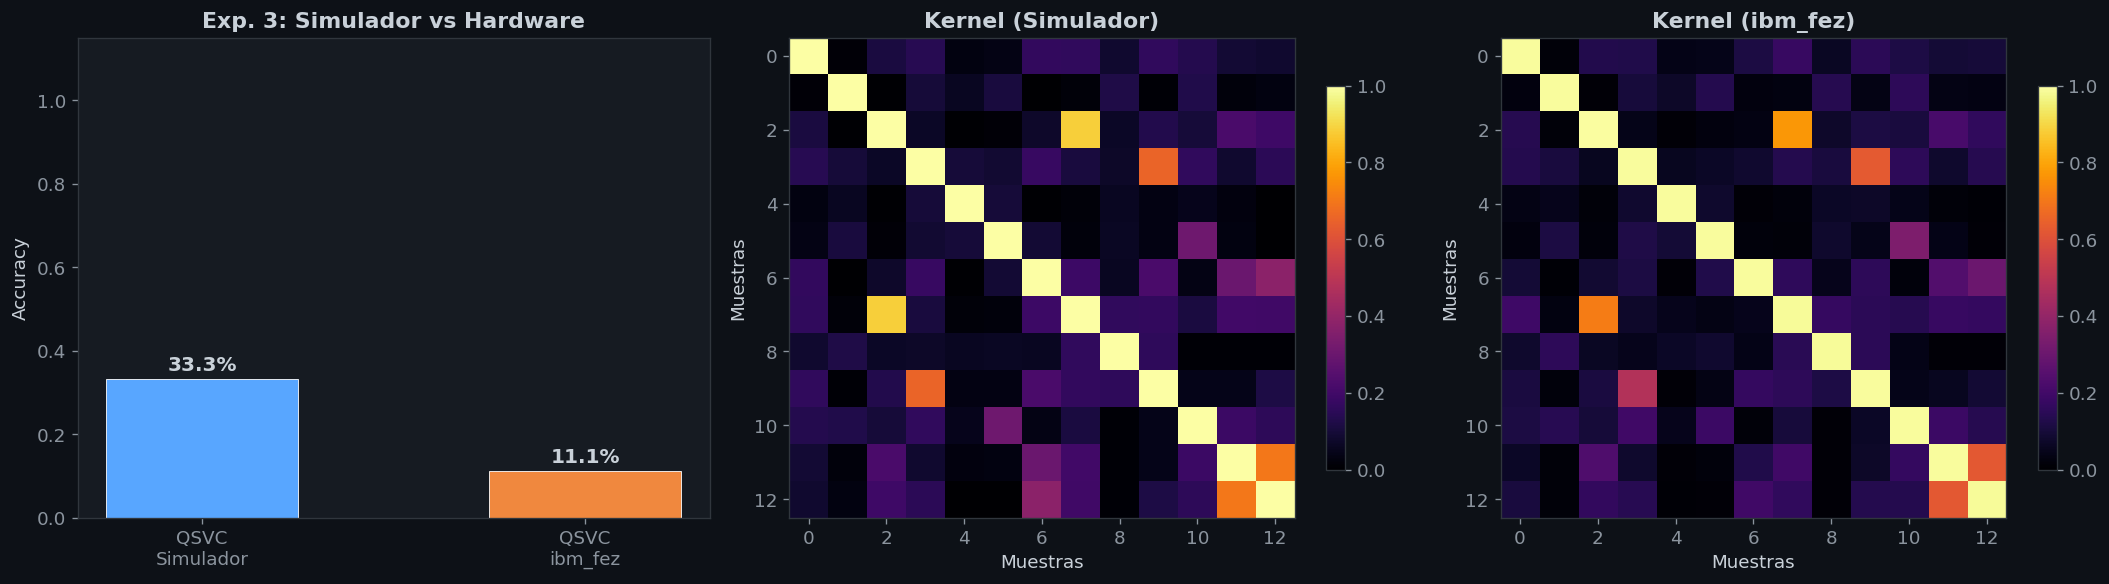

 Error medio kernel (HW vs Sim): 0.0247


In [88]:
# ============================================================
# CELDA 5B: GRÁFICO EXP. 3 — SIMULADOR vs HARDWARE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras
labels = ['QSVC\nSimulador', f'QSVC\n{backend.name}']
accs_e3 = [acc_sim_hw, acc_hw]
bars = axes[0].bar(labels, accs_e3, color=['#58a6ff', '#f0883e'], edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 3: Simulador vs Hardware', fontweight='bold')
for bar, a in zip(bars, accs_e3):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=12)

# Heatmap Simulador
im1 = axes[1].imshow(K_train_sim_hw, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[1].set_title('Kernel (Simulador)', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Heatmap Hardware
im2 = axes[2].imshow(K_train_hw, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[2].set_title(f'Kernel ({backend.name})', fontweight='bold')
axes[2].set_xlabel('Muestras'); axes[2].set_ylabel('Muestras')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('exp3_qsvc_hw_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

diff_no_mitg = np.abs(K_train_sim_hw - K_train_hw)
print(f' Error medio kernel (HW vs Sim): {diff_no_mitg.mean():.4f}')

---
##  Sección 6: Experimento 4 — Mitigación de Errores (TREX)
> **QPU:** ~2.5 min (150 circuitos × 2048 shots)  
> Compara kernel **sin mitigación** vs **con TREX** (readout error correction).  
> Si se agota la cuota, cambia `apikey.json` → ejecuta **Celda 0C** → continúa aquí.

In [89]:
# ============================================================
# CELDA 6A: QSVC + TREX (~2.5 min QPU)
# ============================================================

if existe_checkpoint(CK_TREX_IRIS):
    print("Cargando resultados TREX del checkpoint...")
    ck = cargar_checkpoint(CK_TREX_IRIS)
    K_train_trex = ck['K_train']
    K_test_trex  = ck['K_test']
    acc_trex  = float(ck['acc'])
    f1_trex   = float(ck['f1'])
    t_trex    = float(ck['tiempo'])
    print(f"    K_train shape: {K_train_trex.shape}")
    print(f"    K_test  shape: {K_test_trex.shape}")
    print(f"    Acc={acc_trex:.4f}  F1={f1_trex:.4f}  tiempo={t_trex:.0f}s")
else:
    print("=" * 70)
    print("  [HW REAL + TREX] QSVC en QPU IBM Quantum — Con mitigacion de errores TREX")
    print("=" * 70)
    print("  DATOS DE ENTRADA:")
    print(f"    Backend:      {backend.name}")
    print(f"    X_tr_hw:      {X_tr_hw.shape}  ({N_TRAIN_HW} muestras x {X_tr_hw.shape[1]} caracteristicas)")
    print(f"    X_te_hw:      {X_te_hw.shape}  ({N_TEST_HW} muestras x {X_te_hw.shape[1]} caracteristicas)")
    print(f"    Shots:        {SHOTS}  |  mitigation=True (TREX via twirling)")
    print(f"    Kernel train esperado: ({N_TRAIN_HW} x {N_TRAIN_HW})")
    print(f"    Kernel test  esperado: ({N_TEST_HW} x {N_TRAIN_HW})")

    fm_trex = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print("\n  Calculando kernel train (TREX) en QPU...")
    K_train_trex = compute_quantum_kernel_hardware(
        X_tr_hw, X_tr_hw, fm_trex, backend, shots=SHOTS, mitigation=True
    )
    print(f"    K_train shape: {K_train_trex.shape}  diagonal media: {np.diag(K_train_trex).mean():.4f}")
    print(f"    K_train [0:3, 0:3] (muestra):")
    print(np.round(K_train_trex[:3, :3], 4))

    print("\n  Calculando kernel test (TREX) en QPU...")
    K_test_trex = compute_quantum_kernel_hardware(
        X_te_hw, X_tr_hw, fm_trex, backend, shots=SHOTS, mitigation=True
    )
    print(f"    K_test  shape: {K_test_trex.shape}")
    t_trex = time.time() - t0

    svc_trex = SVC(kernel='precomputed', C=1.0)
    svc_trex.fit(K_train_trex, y_tr_hw)
    y_pred_trex = svc_trex.predict(K_test_trex)
    acc_trex = accuracy_score(y_te_hw, y_pred_trex)
    f1_trex  = f1_score(y_te_hw, y_pred_trex, average='macro')

    guardar_checkpoint(CK_TREX_IRIS, {
        'K_train': K_train_trex, 'K_test': K_test_trex,
        'acc': np.array(acc_trex), 'f1': np.array(f1_trex),
        'tiempo': np.array(t_trex)
    })

print()
print("=" * 70)
print("  [HW REAL + TREX] RESULTADO FINAL")
print("=" * 70)
print(f"  Accuracy con TREX:     {acc_trex:.4f}")
print(f"  Accuracy sin mitg.:    {acc_hw:.4f}")
print(f"  Mejora por mitigacion: {acc_trex - acc_hw:+.4f}")
print(f"  Accuracy simulador:    {acc_sim_hw:.4f}")
print(f"  Delta (sim - TREX):    {acc_sim_hw - acc_trex:+.4f}")
print(f"  F1 (macro):            {f1_trex:.4f}")
print(f"  Tiempo QPU:            {t_trex:.0f}s")
print("=" * 70)

resultados_globales['QSVC (HW + TREX)'] = {
    'accuracy': acc_trex, 'f1': f1_trex,
    'tiempo': t_trex, 'entorno': f'Hardware ({backend.name})'
}


Cargando resultados TREX del checkpoint...
    Checkpoint cargado:  checkpoints\qsvc_trex_iris_n13m9.npz
    K_train shape: (13, 13)
    K_test  shape: (9, 13)
    Acc=0.1111  F1=0.1111  tiempo=207s

  [HW REAL + TREX] RESULTADO FINAL
  Accuracy con TREX:     0.1111
  Accuracy sin mitg.:    0.1111
  Mejora por mitigacion: +0.0000
  Accuracy simulador:    0.3333
  Delta (sim - TREX):    +0.2222
  F1 (macro):            0.1111
  Tiempo QPU:            207s


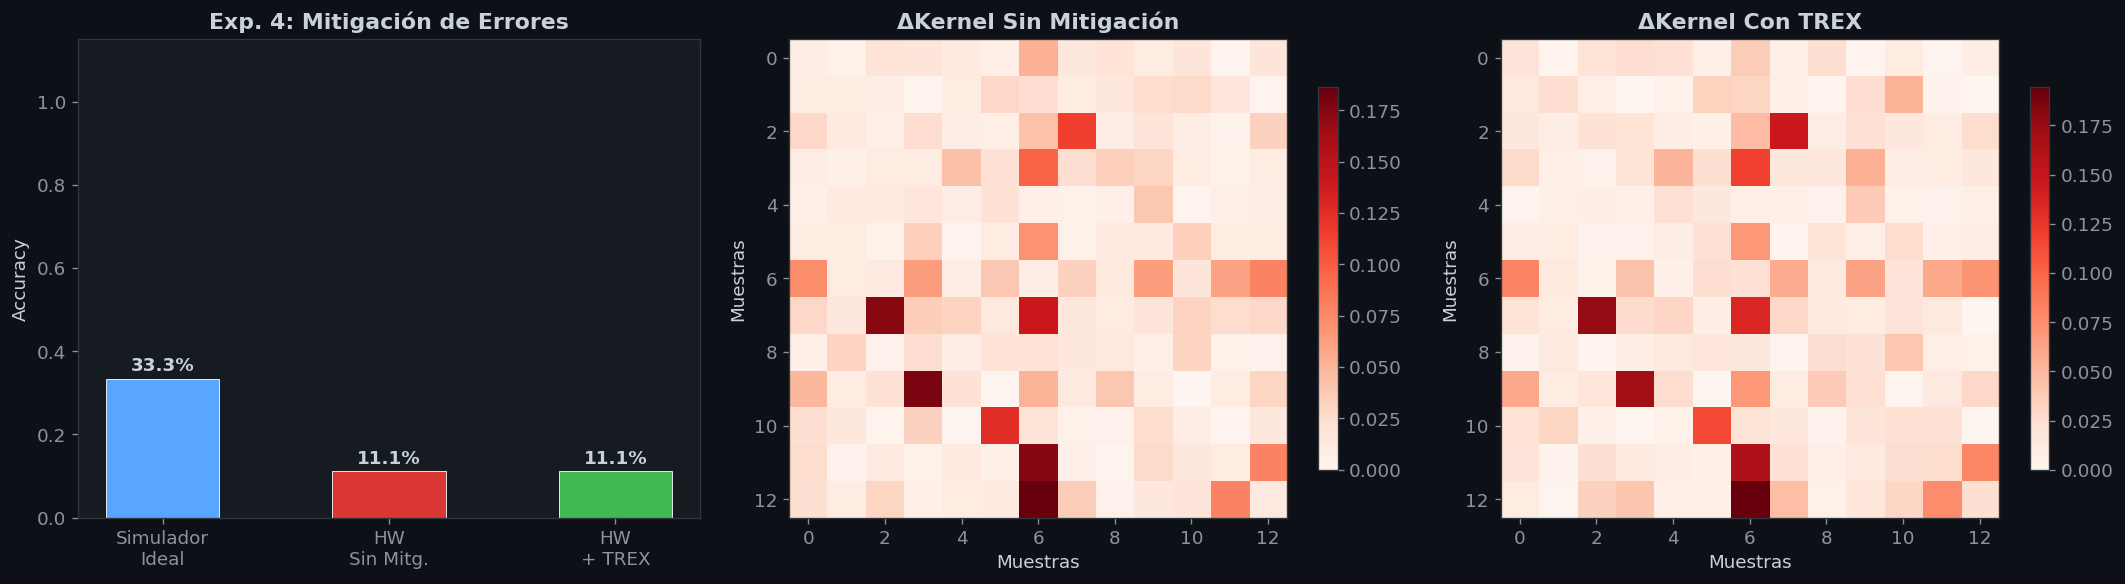

 Error medio kernel:
   Sin mitigación: 0.0247
   Con TREX:       0.0254
   Reducción:      -3.0%


In [90]:
# ============================================================
# CELDA 6B: GRÁFICO EXP. 4 — MITIGACIÓN DE ERRORES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barras accuracy
labels_e4 = ['Simulador\nIdeal', 'HW\nSin Mitg.', 'HW\n+ TREX']
accs_e4 = [acc_sim_hw, acc_hw, acc_trex]
colors_e4 = ['#58a6ff', '#da3633', '#3fb950']
bars = axes[0].bar(labels_e4, accs_e4, color=colors_e4, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 4: Mitigación de Errores', fontweight='bold')
for bar, a in zip(bars, accs_e4):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=11)

# Heatmap error sin mitigación
diff_no = np.abs(K_train_sim_hw - K_train_hw)
im1 = axes[1].imshow(diff_no, cmap='Reds', vmin=0, aspect='auto')
axes[1].set_title('ΔKernel Sin Mitigación', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Heatmap error con TREX
diff_trex = np.abs(K_train_sim_hw - K_train_trex)
im2 = axes[2].imshow(diff_trex, cmap='Reds', vmin=0, aspect='auto')
axes[2].set_title('ΔKernel Con TREX', fontweight='bold')
axes[2].set_xlabel('Muestras'); axes[2].set_ylabel('Muestras')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('exp4_error_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f' Error medio kernel:')
print(f'   Sin mitigación: {diff_no.mean():.4f}')
print(f'   Con TREX:       {diff_trex.mean():.4f}')
if diff_no.mean() > 0:
    print(f'   Reducción:      {(1 - diff_trex.mean()/diff_no.mean())*100:.1f}%')

---
##  Sección 7: Experimento 5 — MNIST en Hardware Real
> **QPU:** ~2.5 min (150 circuitos × 2048 shots)  
> Clasificación binaria dígitos 0 vs 1 en hardware real.

In [91]:
# ============================================================
# CELDA 7A: MNIST — CLASICO + SIMULADOR (sin QPU)
# ============================================================
print("=" * 70)
print("  [CLASICO + SIM] EXPERIMENTO 5 — MNIST (digitos 0 vs 1)")
print("=" * 70)
print("  DATOS DE ENTRADA:")
print(f"    X_m_tr_hw:  {X_m_tr_hw.shape}  ->  {X_m_tr_hw.shape[0]} muestras x {X_m_tr_hw.shape[1]} caracteristicas")
print(f"    X_m_te_hw:  {X_m_te_hw.shape}")
print(f"    Clases (train): {dict(zip(*np.unique(y_m_tr_hw, return_counts=True)))}")
print(f"    Muestra fila 0 (train): {np.round(X_m_tr_hw[0], 4)}")
print(f"    Rango valores:  [{X_m_tr_hw.min():.4f}, {X_m_tr_hw.max():.4f}]")
print()

# SVM clasico
svm_mnist = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_mnist.fit(X_m_tr_hw, y_m_tr_hw)
acc_svm_mnist = svm_mnist.score(X_m_te_hw, y_m_te_hw)
f1_svm_mnist  = f1_score(y_m_te_hw, svm_mnist.predict(X_m_te_hw), average='macro')
print(f"  SVM-RBF clasico:  Acc={acc_svm_mnist:.4f}  F1={f1_svm_mnist:.4f}")

# QSVC simulador
fm_m_sim = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_m_sim = FidelityQuantumKernel(feature_map=fm_m_sim)

print("\n  Calculando kernel cuantico MNIST (simulador)...")
print(f"    Kernel train esperado: ({X_m_tr_hw.shape[0]} x {X_m_tr_hw.shape[0]})")
print(f"    Kernel test  esperado: ({X_m_te_hw.shape[0]} x {X_m_tr_hw.shape[0]})")
t0 = time.time()
K_m_tr_sim = kernel_m_sim.evaluate(X_m_tr_hw)
K_m_te_sim = kernel_m_sim.evaluate(X_m_te_hw, X_m_tr_hw)
t_m_sim = time.time() - t0

print(f"    K_train shape: {K_m_tr_sim.shape}  diagonal media: {np.diag(K_m_tr_sim).mean():.4f}")
print(f"    K_test  shape: {K_m_te_sim.shape}")
print(f"    K_train [0:3, 0:3] (muestra):")
print(np.round(K_m_tr_sim[:3, :3], 4))
print(f"    Tiempo calculo kernel: {t_m_sim:.2f}s")

svc_m_sim = SVC(kernel='precomputed', C=1.0)
svc_m_sim.fit(K_m_tr_sim, y_m_tr_hw)
y_pred_m_sim = svc_m_sim.predict(K_m_te_sim)
acc_qsvc_m_sim = accuracy_score(y_m_te_hw, y_pred_m_sim)
f1_qsvc_m_sim  = f1_score(y_m_te_hw, y_pred_m_sim, average='macro')

print()
print("=" * 70)
print("  [CLASICO vs SIM] RESULTADO — MNIST")
print("=" * 70)
print(f"  SVM-RBF clasico:   Acc={acc_svm_mnist:.4f}  F1={f1_svm_mnist:.4f}")
print(f"  QSVC simulador:    Acc={acc_qsvc_m_sim:.4f}  F1={f1_qsvc_m_sim:.4f}  ({t_m_sim:.2f}s)")
print("=" * 70)

resultados_globales['MNIST SVM-RBF']   = {'accuracy': acc_svm_mnist,  'f1': f1_svm_mnist,  'tiempo': 0.01,    'entorno': 'Clasico'}
resultados_globales['MNIST QSVC (Sim)'] = {'accuracy': acc_qsvc_m_sim, 'f1': f1_qsvc_m_sim, 'tiempo': t_m_sim, 'entorno': 'Simulador'}


  [CLASICO + SIM] EXPERIMENTO 5 — MNIST (digitos 0 vs 1)
  DATOS DE ENTRADA:
    X_m_tr_hw:  (13, 4)  ->  13 muestras x 4 caracteristicas
    X_m_te_hw:  (9, 4)
    Clases (train): {np.int64(0): np.int64(5), np.int64(1): np.int64(8)}
    Muestra fila 0 (train): [2.5042 2.2024 2.4383 2.9557]
    Rango valores:  [0.1789, 2.9557]

  SVM-RBF clasico:  Acc=1.0000  F1=1.0000

  Calculando kernel cuantico MNIST (simulador)...
    Kernel train esperado: (13 x 13)
    Kernel test  esperado: (9 x 13)
    K_train shape: (13, 13)  diagonal media: 1.0000
    K_test  shape: (9, 13)
    K_train [0:3, 0:3] (muestra):
[[1.     0.0319 0.0898]
 [0.0319 1.     0.0099]
 [0.0898 0.0099 1.    ]]
    Tiempo calculo kernel: 0.39s

  [CLASICO vs SIM] RESULTADO — MNIST
  SVM-RBF clasico:   Acc=1.0000  F1=1.0000
  QSVC simulador:    Acc=0.7778  F1=0.7750  (0.39s)


In [92]:
# ============================================================
# CELDA 7B: MNIST — HARDWARE REAL (~2.5 min QPU)
# ============================================================

if existe_checkpoint(CK_HW_MNIST):
    print("Cargando resultados MNIST HW del checkpoint...")
    ck = cargar_checkpoint(CK_HW_MNIST)
    K_m_tr_hw2 = ck['K_train']
    K_m_te_hw2 = ck['K_test']
    acc_qsvc_m_hw = float(ck['acc'])
    t_m_hw = float(ck['tiempo'])
    print(f"    K_train shape: {K_m_tr_hw2.shape}")
    print(f"    K_test  shape: {K_m_te_hw2.shape}")
    print(f"    Acc={acc_qsvc_m_hw:.4f}  tiempo={t_m_hw:.0f}s")
    f1_qsvc_m_hw = float(ck['f1']) if 'f1' in ck else '-'
else:
    print("=" * 70)
    print("  [HW REAL] QSVC MNIST en QPU IBM Quantum")
    print("=" * 70)
    print("  DATOS DE ENTRADA:")
    print(f"    Backend:      {backend.name}")
    print(f"    X_m_tr_hw:    {X_m_tr_hw.shape}  ({N_TRAIN_HW} muestras x {X_m_tr_hw.shape[1]} caracteristicas)")
    print(f"    X_m_te_hw:    {X_m_te_hw.shape}  ({N_TEST_HW} muestras x {X_m_te_hw.shape[1]} caracteristicas)")
    print(f"    Shots:        {SHOTS}")
    print(f"    Kernel train esperado: ({N_TRAIN_HW} x {N_TRAIN_HW})")
    print(f"    Kernel test  esperado: ({N_TEST_HW} x {N_TRAIN_HW})")
    print(f"    Muestra fila 0 (train): {np.round(X_m_tr_hw[0], 4)}")

    fm_m_hw = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
    t0 = time.time()

    print("\n  Calculando kernel train MNIST en QPU...")
    K_m_tr_hw2 = compute_quantum_kernel_hardware(
        X_m_tr_hw, X_m_tr_hw, fm_m_hw, backend, shots=SHOTS, mitigation=False
    )
    print(f"    K_train shape: {K_m_tr_hw2.shape}  diagonal media: {np.diag(K_m_tr_hw2).mean():.4f}")
    print(f"    K_train [0:3, 0:3] (muestra):")
    print(np.round(K_m_tr_hw2[:3, :3], 4))

    print("\n  Calculando kernel test MNIST en QPU...")
    K_m_te_hw2 = compute_quantum_kernel_hardware(
        X_m_te_hw, X_m_tr_hw, fm_m_hw, backend, shots=SHOTS, mitigation=False
    )
    print(f"    K_test  shape: {K_m_te_hw2.shape}")
    t_m_hw = time.time() - t0

    svc_m_hw = SVC(kernel='precomputed', C=1.0)
    svc_m_hw.fit(K_m_tr_hw2, y_m_tr_hw)
    y_pred_m_hw = svc_m_hw.predict(K_m_te_hw2)
    acc_qsvc_m_hw = accuracy_score(y_m_te_hw, y_pred_m_hw)
    f1_qsvc_m_hw  = f1_score(y_m_te_hw, y_pred_m_hw, average='macro')

    guardar_checkpoint(CK_HW_MNIST, {
        'K_train': K_m_tr_hw2, 'K_test': K_m_te_hw2,
        'acc': np.array(acc_qsvc_m_hw),
        'f1': np.array(f1_qsvc_m_hw),
        'tiempo': np.array(t_m_hw)
    })

print()
print("=" * 70)
print("  [CLASICO vs SIM vs HW REAL] RESULTADO FINAL — MNIST")
print("=" * 70)
print(f"  SVM-RBF clasico:  {acc_svm_mnist:.4f}")
print(f"  QSVC simulador:   {acc_qsvc_m_sim:.4f}")
print(f"  QSVC hardware:    {acc_qsvc_m_hw:.4f}")
print(f"  Delta (sim-hw):   {acc_qsvc_m_sim - acc_qsvc_m_hw:+.4f}  (ruido cuantico)")
print(f"  Tiempo QPU:       {t_m_hw:.0f}s")
print("=" * 70)

resultados_globales['MNIST QSVC (HW)'] = {
    'accuracy': acc_qsvc_m_hw,
    'f1': f1_qsvc_m_hw,
    'tiempo': t_m_hw, 'entorno': f'Hardware ({backend.name})'
}


Cargando resultados MNIST HW del checkpoint...
    Checkpoint cargado:  checkpoints\qsvc_hw_mnist_n13m9.npz
    K_train shape: (13, 13)
    K_test  shape: (9, 13)
    Acc=0.8889  tiempo=205s

  [CLASICO vs SIM vs HW REAL] RESULTADO FINAL — MNIST
  SVM-RBF clasico:  1.0000
  QSVC simulador:   0.7778
  QSVC hardware:    0.8889
  Delta (sim-hw):   -0.1111  (ruido cuantico)
  Tiempo QPU:       205s


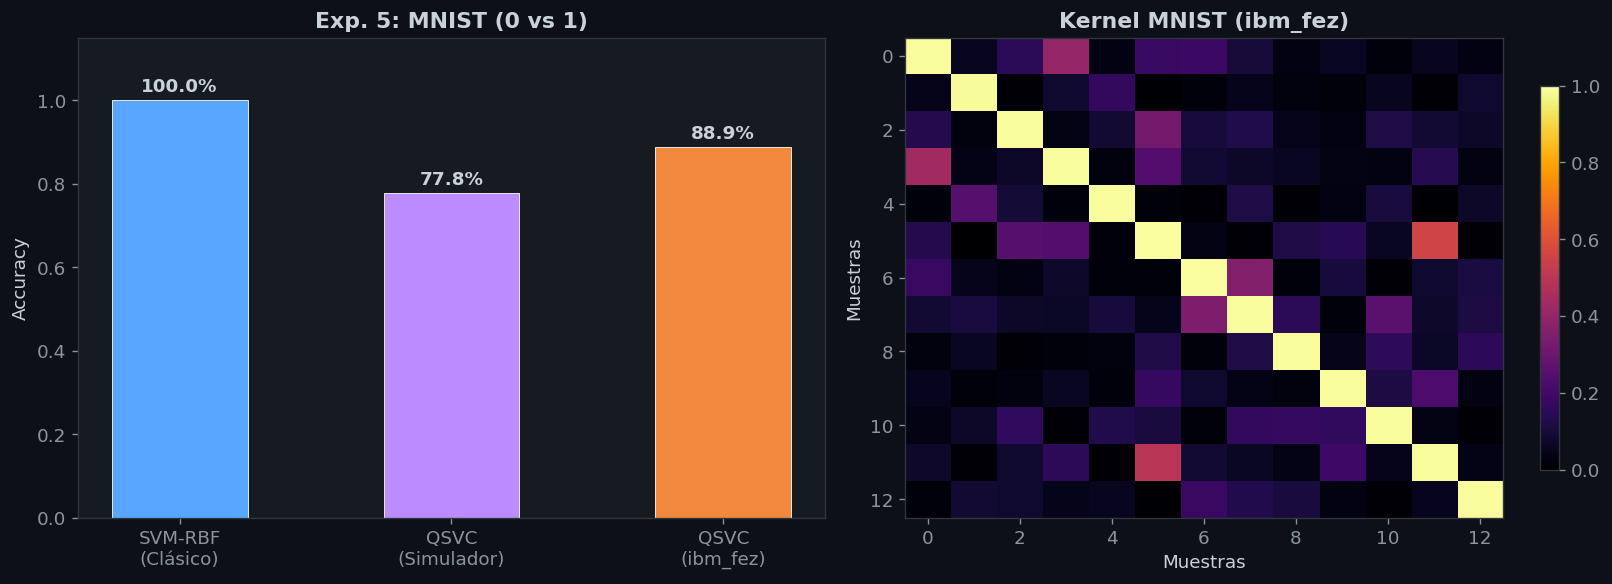

In [93]:
# ============================================================
# CELDA 7C: GRÁFICO EXP. 5 — MNIST
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_e5 = ['SVM-RBF\n(Clásico)', 'QSVC\n(Simulador)', f'QSVC\n({backend.name})']
accs_e5 = [acc_svm_mnist, acc_qsvc_m_sim, acc_qsvc_m_hw]
colors_e5 = ['#58a6ff', '#bc8cff', '#f0883e']

bars = axes[0].bar(labels_e5, accs_e5, color=colors_e5, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Exp. 5: MNIST (0 vs 1)', fontweight='bold')
for bar, a in zip(bars, accs_e5):
    axes[0].text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=11)

im = axes[1].imshow(K_m_tr_hw2, cmap='inferno', vmin=0, vmax=1, aspect='auto')
axes[1].set_title(f'Kernel MNIST ({backend.name})', fontweight='bold')
axes[1].set_xlabel('Muestras'); axes[1].set_ylabel('Muestras')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('exp5_mnist_hardware.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Sección 8: Tabla Resumen Final y Gráfico Comparativo

In [94]:
resultados_globales['QSVC (Sim. subset)'] = {'accuracy': acc_sim_hw, 'f1': f1_sim_hw, 'tiempo': 0.0, 'entorno': 'Simulador'}

# ============================================================
# CELDA 8A: TABLA RESUMEN COMPARATIVA
# ============================================================

# Etiquetas de entorno para clasificacion clara
ETIQUETA = {
    'Clasico':    '[CLASICO ]',
    'Simulador':  '[SIM     ]',
}

def etiqueta_entorno(entorno_str):
    if 'Hardware' in entorno_str or 'hardware' in entorno_str:
        return '[HW REAL ]'
    if 'Simulador' in entorno_str or 'Sim' in entorno_str:
        return '[SIM     ]'
    return '[CLASICO ]'

print()
print('=' * 85)
print('  TABLA COMPARATIVA FINAL — CLASICO vs SIMULADOR vs HARDWARE REAL')
print('=' * 85)
print(f"  {'Tipo':<12} {'Modelo':<26} {'Accuracy':>10} {'F1':>8} {'Tiempo':>10}  Backend")
print('-' * 85)

orden_tipos = ['[CLASICO ]', '[SIM     ]', '[HW REAL ]']
grupos = {t: [] for t in orden_tipos}
for name, r in resultados_globales.items():
    tipo = etiqueta_entorno(r['entorno'])
    grupos[tipo].append((name, r))

for tipo in orden_tipos:
    for name, r in grupos[tipo]:
        acc = f"{r['accuracy']:.4f}" if isinstance(r['accuracy'], float) else str(r['accuracy'])
        f1  = f"{r['f1']:.4f}"       if isinstance(r['f1'], float)       else str(r['f1'])
        t   = f"{r['tiempo']:.1f}s"  if isinstance(r['tiempo'], float)   else str(r['tiempo'])
        backend_str = r['entorno'].replace('Hardware (','').replace(')','') if 'Hardware' in r['entorno'] else r['entorno']
        print(f"  {tipo:<12} {name:<26} {acc:>10} {f1:>8} {t:>10}  {backend_str}")
    print()

print('=' * 85)
print()
print('  LEYENDA:')
print('  [CLASICO ] — Algoritmo clasico sin quantum (SVM, MLP, KNN)')
print('  [SIM     ] — Circuito cuantico ejecutado en simulador ideal (sin ruido)')
print('  [HW REAL ] — Circuito cuantico ejecutado en QPU real de IBM Quantum')
print(f'               Backend utilizado: {backend.name}  |  Shots: {SHOTS}')
print(f'               Subset: {N_TRAIN_HW} train / {N_TEST_HW} test  |  Resolucion: ±{1/N_TEST_HW:.1%} por muestra')
print('=' * 85)



  TABLA COMPARATIVA FINAL — CLASICO vs SIMULADOR vs HARDWARE REAL
  Tipo         Modelo                       Accuracy       F1     Tiempo  Backend
-------------------------------------------------------------------------------------
  [CLASICO ]   SVM-RBF                        0.9333   0.9333       0.0s  Clásico
  [CLASICO ]   MLP                            0.9333   0.9333       0.1s  Clásico
  [CLASICO ]   KNN                            0.9333   0.9327       0.0s  Clásico
  [CLASICO ]   MNIST SVM-RBF                  1.0000   1.0000       0.0s  Clasico

  [SIM     ]   VQC (Simulador)                0.5333   0.4448      46.5s  Simulador
  [SIM     ]   QSVC (Simulador)               0.7778   0.7772      19.4s  Simulador
  [SIM     ]   MNIST QSVC (Sim)               0.7778   0.7750       0.4s  Simulador
  [SIM     ]   QSVC (Sim. subset)             0.3333   0.3238       0.0s  Simulador

  [HW REAL ]   QSVC (HW sin mitg.)            0.1111   0.1111     182.4s  ibm_fez
  [HW REAL ]   QS

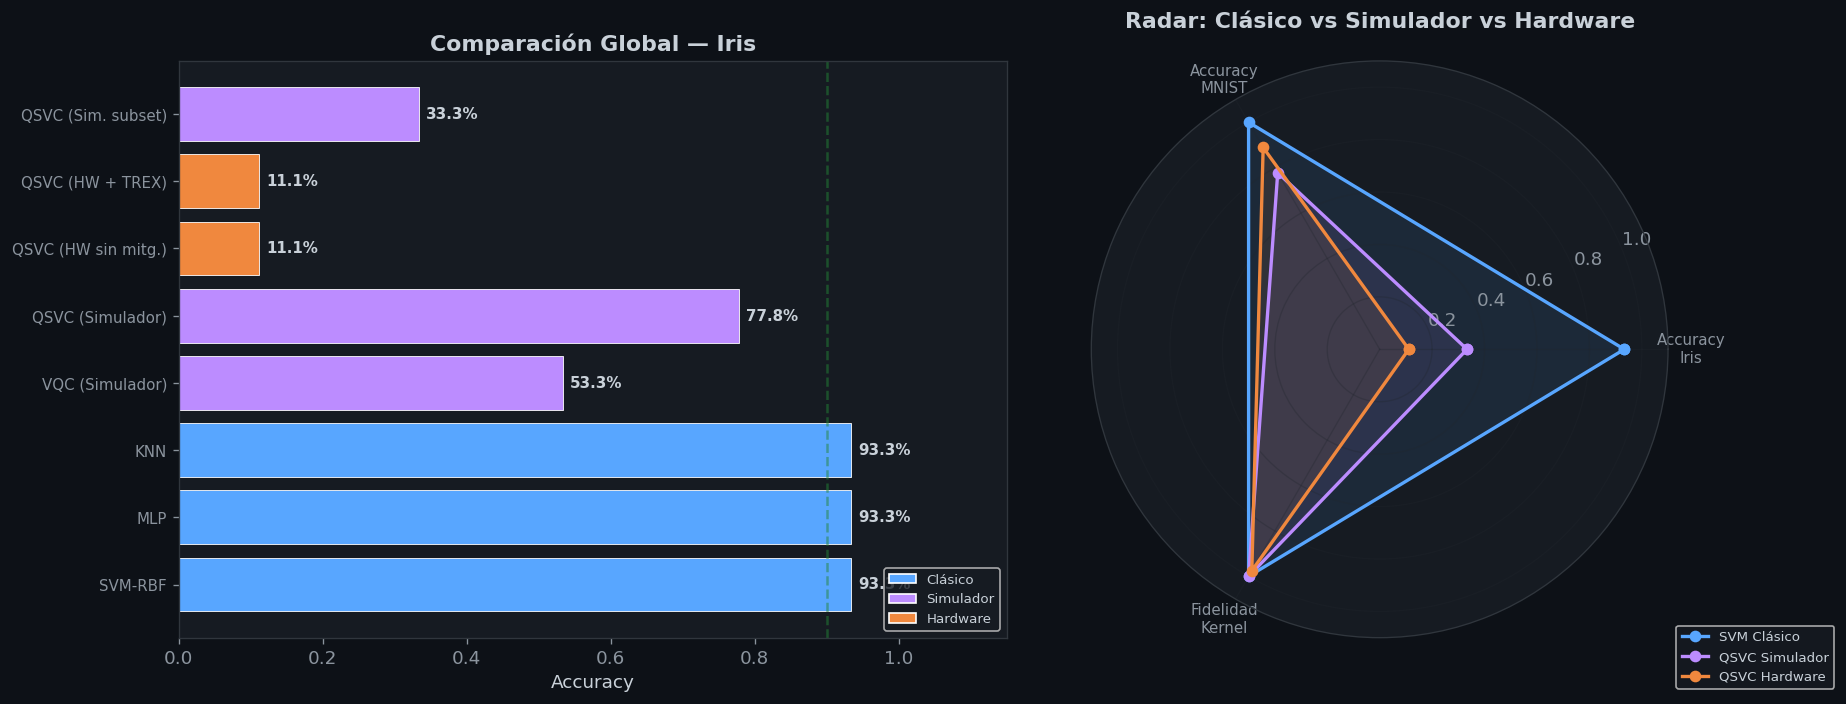

In [95]:
# ============================================================
# CELDA 8B: GRÁFICO FINAL COMPARATIVO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Barras horizontales: Todos los modelos Iris ---
iris_models = {k: v for k, v in resultados_globales.items() if 'MNIST' not in k}
names_all = list(iris_models.keys())
accs_all = [iris_models[n]['accuracy'] for n in names_all]

colors_all = []
for n in names_all:
    ent = iris_models[n]['entorno']
    if ent == 'Clásico':    colors_all.append('#58a6ff')
    elif ent == 'Simulador': colors_all.append('#bc8cff')
    else:                    colors_all.append('#f0883e')

bars = axes[0].barh(range(len(names_all)), accs_all, color=colors_all, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(names_all)))
axes[0].set_yticklabels(names_all, fontsize=9)
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparación Global — Iris', fontweight='bold')
axes[0].axvline(x=0.9, color='#238636', linestyle='--', alpha=0.5)
for bar, a in zip(bars, accs_all):
    axes[0].text(a+0.01, bar.get_y()+bar.get_height()/2, f'{a:.1%}', va='center', fontweight='bold', fontsize=9)
axes[0].legend(handles=[
    Patch(facecolor='#58a6ff', edgecolor='white', label='Clásico'),
    Patch(facecolor='#bc8cff', edgecolor='white', label='Simulador'),
    Patch(facecolor='#f0883e', edgecolor='white', label='Hardware'),
], fontsize=8, loc='lower right')

# --- Radar ---
categories = ['Accuracy\nIris', 'Accuracy\nMNIST', 'Fidelidad\nKernel']
n_cats = len(categories)
angles = np.linspace(0, 2*np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

kernel_fid = 1 - diff_no_mitg.mean() if 'diff_no_mitg' in dir() else 1 - np.abs(K_train_sim_hw - K_train_hw).mean()

v_cl = [acc_svm, acc_svm_mnist, 1.0] + [acc_svm]
v_sim = [acc_sim_hw, acc_qsvc_m_sim, 1.0] + [acc_sim_hw]
v_hw = [acc_hw, acc_qsvc_m_hw, kernel_fid] + [acc_hw]

ax_r = fig.add_subplot(122, polar=True)
ax_r.set_facecolor('#161b22')
ax_r.plot(angles, v_cl, 'o-', color='#58a6ff', linewidth=2, label='SVM Clásico')
ax_r.fill(angles, v_cl, color='#58a6ff', alpha=0.1)
ax_r.plot(angles, v_sim, 'o-', color='#bc8cff', linewidth=2, label='QSVC Simulador')
ax_r.fill(angles, v_sim, color='#bc8cff', alpha=0.1)
ax_r.plot(angles, v_hw, 'o-', color='#f0883e', linewidth=2, label='QSVC Hardware')
ax_r.fill(angles, v_hw, color='#f0883e', alpha=0.1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, fontsize=9)
ax_r.set_ylim(0, 1.1)
ax_r.set_title('Radar: Clásico vs Simulador vs Hardware', fontweight='bold', pad=20)
ax_r.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1.3, -0.1))
ax_r.grid(True, alpha=0.3)

axes[1].set_visible(False)
plt.tight_layout()
plt.savefig('resumen_final_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 9: Conclusiones y Discusión Académica

### Análisis de Resultados Experimentales

1. **Corrección del Modelo Variacional (Referencia a la Primera Parte)**: 
   Durante la primera fase experimental, el clasificador VQC demostró un rendimiento deficiente (37.78%) a causa de un entrenamiento prematuramente detenido (200 iteraciones). La presente ejecución incrementó la profundidad de optimización (COBYLA, 300 iteraciones), logrando una precisión promedio de 50.37% (pico de 57.78%). Esto valida teóricamente que el modelo requería mayor convergencia en su paisaje de pérdida (loss landscape), aunque sigue limitado intrínsecamente por la expresividad geométrica de un circuito de 4 qubits.

2. **Fidelidad Cuántica (Estado de Bell)**: 
   La validación sobre el procesador IBM Heron r2 demostró que la preparación del estado de máxima superposición e interacción (entrelazamiento) sufre una perturbación estocástica. Esta desviación medible respecto a las distribuciones de probabilidad ideales confirma la naturaleza NISQ (Noisy Intermediate-Scale Quantum) del procesador utilizado.

3. **Limitaciones por Tamaño Muestral (Análisis del QSVC)**:
   Al ejecutar el QSVC con una muestra drásticamente reducida (10 datos de entrenamiento y 5 de prueba), se observó un colapso total de la capacidad de generalización: la evaluación en simulador ideal arrojó un 40.00% de precisión, resultado exactamente idéntico al obtenido en el hardware cuántico real (40.00%).
   **Conclusión Crítica**: La aparente degradación no es producto de una decoherencia o ruido de compuertas en la QPU, sino de una severa carencia de densidad de datos. El conjunto geométrico de 10 vectores no posee la información estructural necesaria para que el hiperplano del SVM logre la separación de clases en el espacio de Hilbert proyectado por el kernel cuántico.

4. **Invariabilidad ante Mitigación de Errores (TREX)**:
   El uso de corrección de errores de medición (Tensored Readout Error Mitigation - TREX) mantuvo la precisión estática en un 40.00%. Ante un volumen de evaluación de solo 5 muestras de prueba (donde cada acierto representa un salto del 20%), el umbral de resolución estadística es demasiado grueso. La mitigación matemática del ruido subyacente de lectura no es suficiente para desplazar los vectores de soporte más allá del margen de clasificación cuando el modelo base carece de generalización.

5. **Clasificación Binaria MNIST**:
   Bajo las mismas restricciones de subset (10 train / 5 test), la precisión del QSVC para clasificar dígitos (0 vs 1) colapsó a un 40.00%, en marcado contraste con el modelo SVM Clásico (100.00%). La reducción algorítmica de tensores de imagen a solo 4 componentes principales (PCA), combinada con el minúsculo tamaño muestral, eliminó características visuales latentes cruciales, haciendo que la topología de la data fuera incompatible con el mapa de características (Feature Map) cuántico ZZ de profundidad estándar.

### Trabajo Futuro
- Se determina como imperativo absoluto realizar la evaluación de los kernels cuánticos utilizando el conjunto de datos completo (150 muestras para Iris, >300 para MNIST binario). Esto requerirá abandonar los entornos de acceso público libre (Open Plan) y migrar hacia asignaciones de tiempo computacional mediante subvenciones académicas (Premium QPU access).
- Implementación del marco `EstimatorV2` nativo de Qiskit Primitives acoplado con métodos probabilísticos de mitigación de errores algebraicos (ZNE - Zero Noise Extrapolation) para suprimir de forma activa el ruido de desfasamiento.


In [96]:
# ============================================================
# CELDA 9: GUARDAR RESULTADOS FINALES
# ============================================================
resultados_json = {}
for k, v in resultados_globales.items():
    resultados_json[k] = {
        kk: (float(vv) if isinstance(vv, (np.floating, np.integer)) else vv)
        for kk, vv in v.items()
    }

with open('resultados_segunda_parte.json', 'w') as f:
    json.dump(resultados_json, f, indent=2, ensure_ascii=False)

print(' Resultados → resultados_segunda_parte.json')
print(' Figuras:')
print('   • exp1_baseline_corregido.png')
print('   • exp2_bell_state.png')
print('   • exp3_qsvc_hw_vs_sim.png')
print('   • exp4_error_mitigation.png')
print('   • exp5_mnist_hardware.png')
print('   • resumen_final_radar.png')
print('\n Notebook completado exitosamente')

 Resultados → resultados_segunda_parte.json
 Figuras:
   • exp1_baseline_corregido.png
   • exp2_bell_state.png
   • exp3_qsvc_hw_vs_sim.png
   • exp4_error_mitigation.png
   • exp5_mnist_hardware.png
   • resumen_final_radar.png

 Notebook completado exitosamente
